In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import svd
from statsmodels.multivariate.cancorr import CanCorr
from sparsecca import pmd
import seaborn as sns
import pingouin as pg
from sklearn.cross_decomposition import PLSRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import permutation_test_score
from scipy.stats import pearsonr
from impyute.imputation.cs import mice
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
import missingno as msno
import miceforest as mf
from sklearn.cross_decomposition import CCA
from sklearn.model_selection import KFold
import itertools
import statsmodels.api as sm
from plotnine import *
from pathlib import Path
import re
from statsmodels.stats.multitest import multipletests
from scipy import stats
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from scipy.stats import spearmanr, pearsonr
from plotnine import *
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from sklearn.model_selection import LeaveOneOut, KFold
import io
from PIL import Image

In [2]:
# data path
df = pd.read_excel("Dataset_v2.xlsx")

cols = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T',
       'Unnamed: 32', 'NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%', 'Unnamed: 38',
       'CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg', 'Unnamed: 43', 'CD20T',
       'Unnamed: 45', 'CD4trm', 'CD8trm', 'MAITtrm', 'GD1Ttrm', 'GD2Ttrm',
       'CD4grzk', 'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK', 'Unnamed: 56',
       'Transitional B', 'Memory B', 'Early Plasma B ', 'Plasma B', 'ABC',
       'Unnamed: 62', 'CD11c+CD206-', 'CD11c+CD206+', 'CD11c-CD206+',
       'CD11c-CD206-', 'Dectin-1+1', 'Dectin-1+2', 'Dectin-1+3', 'Dectin-1+4']

# Delete % 
df[cols] = (df[cols]
            .replace(r'^\s*$', pd.NA, regex=True) 
            .replace({',': ''}, regex=True)
            .replace({'%': ''}, regex=True)   
            .apply(pd.to_numeric, errors='coerce'))      


# Delete unnamed columns
df = df.loc[:, ~df.columns.str.contains(r'^Unnamed')]


# Change sex to binary column (0,1)
df['Sex_01'] = df['Sex'].map({'F': 0, 'M': 1})
print(df['Sex_01'].head())


# Seperate to KUMC/AMC
df1 = df.iloc[:22]
df2 = df.iloc[22:]
print(df1.shape, df2.shape)

0    0
1    1
2    1
3    0
4    1
Name: Sex_01, dtype: int64
(22, 67) (22, 67)


In [3]:
df1.head()

,ID,Sex,Age,BMI,AST,ALT,ALP,Bilirubin,Protein,Albumin,...,CD11c+CD206+,CD11c-CD206+,CD11c-CD206-,Dectin-1+1,Dectin-1+2,Dectin-1+3,Dectin-1+4,Gulucose,Total,Sex_01
0,KUMC039,F,66,20.14,40,36,71.0,0.53,7.0,4.6,...,15.0,21.00,14.70,18.20,22.70,19.20,10.80,126,110799.898324,0
1,KUMC040,M,78,24.54,36,26,75.0,1.32,7.5,4.3,...,23.9,6.04,8.41,1.15,2.06,1.23,1.28,101,194145.045730,1
2,KUMC041,M,47,24.89,22,13,65.0,0.41,6.8,4.6,...,12.9,6.28,13.30,5.97,8.83,12.60,2.02,111,29081.958247,1
3,KUMC042,F,66,25.29,28,16,81.0,0.72,6.8,4.5,...,19.0,19.00,8.40,6.66,11.10,12.80,3.81,93,64818.389623,0
4,KUMC045,M,66,21.59,28,21,51.0,1.10,6.9,4.2,...,27.0,0.97,10.50,2.56,6.83,2.20,3.17,93,79074.241203,1


In [4]:
df2.head()

,ID,Sex,Age,BMI,AST,ALT,ALP,Bilirubin,Protein,Albumin,...,CD11c+CD206+,CD11c-CD206+,CD11c-CD206-,Dectin-1+1,Dectin-1+2,Dectin-1+3,Dectin-1+4,Gulucose,Total,Sex_01
22,5,F,29,23.77,17,7,45.0,0.3,NaN,4.1,...,22.3,1.90,3.08,5.77,5.14,10.00,0.00,104,2103.528256,0
23,6,M,58,24.91,17,16,76.0,0.7,NaN,3.8,...,28.7,4.25,13.40,5.98,10.70,4.26,5.31,97,11626.659801,1
24,7,M,22,19.75,14,24,79.0,0.9,NaN,4.2,...,22.9,2.57,8.43,1.15,5.62,6.05,0.67,91,1864.599859,1
25,8,M,51,24.84,19,18,108.0,0.4,NaN,4.5,...,26.5,2.10,8.27,0.42,2.72,2.38,0.00,86,19852.615220,1
26,9,F,67,25.82,19,15,79.0,0.4,NaN,4.2,...,13.4,0.42,1.73,1.54,5.05,3.18,0.41,89,NaN,0


# Task1

### 1. PLSR - PAN%


===== KUMC PAN% vs Age : PLSR metrics =====
n                 : 22
n_components      : 1
cv_mode           : kfold
n_splits          : 5
fit_spearman      : 0.3992
fit_spearman_p    : 0.0657
fit_pearson       : 0.3919
fit_pearson_p     : 0.0713
apparent_r2       : 0.1536
cv_spearman       : 0.1880
cv_spearman_p     : 0.4020
cv_pearson        : 0.1410
cv_pearson_p      : 0.5314
q2_cv             : -0.0607
rmsecv            : 1.1513
p_perm_q2         : 0.2314
q_perm_q2         : 0.2314

===== AMC PAN% vs Age : PLSR metrics =====
n                 : 22
n_components      : 1
cv_mode           : kfold
n_splits          : 5
fit_spearman      : 0.6827
fit_spearman_p    : 0.0005
fit_pearson       : 0.6708
fit_pearson_p     : 0.0006
apparent_r2       : 0.4499
cv_spearman       : 0.5246
cv_spearman_p     : 0.0122
cv_pearson        : 0.5825
cv_pearson_p      : 0.0044
q2_cv             : 0.3023
rmsecv            : 0.8885
p_perm_q2         : 0.0050
q_perm_q2         : 0.0100

===== KUMC PAN% loadi

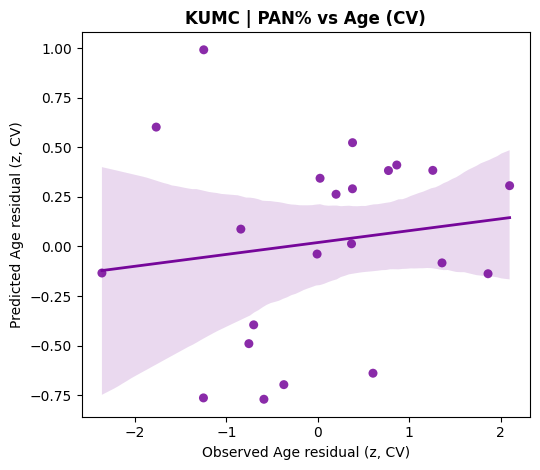

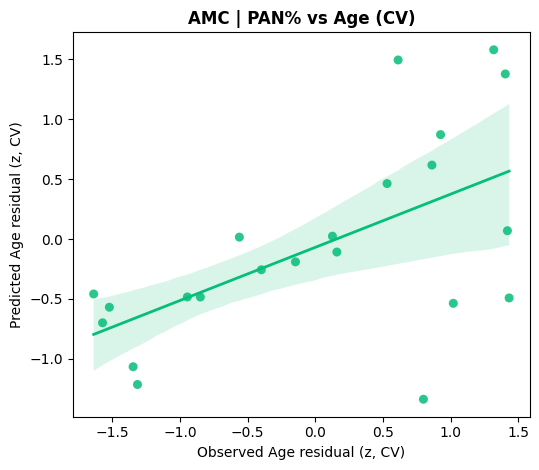

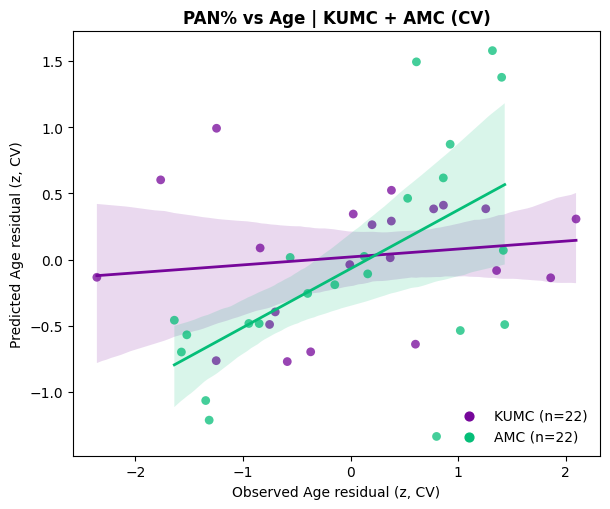

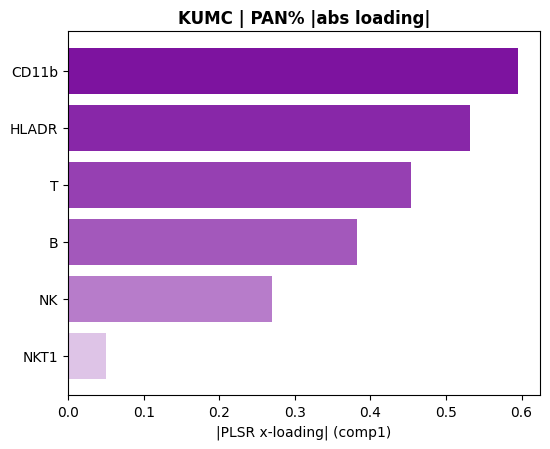

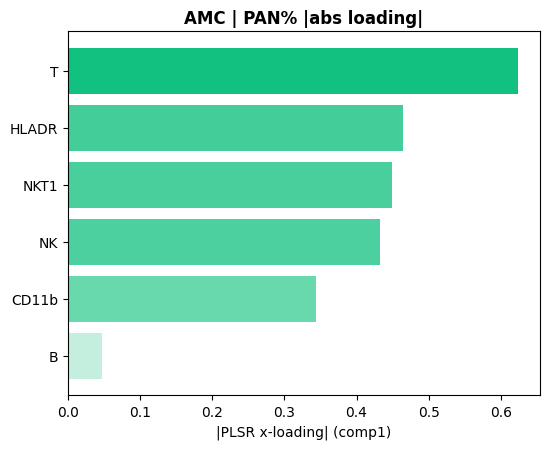

In [5]:
PAN_FEATURES = ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T']
Y_COL = "Age"
COV_COLS = ["Sex_01", "BMI"]

N_COMPONENTS = 1
N_PERM = 2000
RANDOM_SEED = 42

CV_MODE = "kfold"
N_SPLITS = 5

KUMC_COLOR = "#76069A"
AMC_COLOR  = "#05BE78"

SAVE_DIR = "."
SAVE_PREFIX = "PAN_Age"


def residualize_matrix(df_mat: pd.DataFrame, cov: pd.DataFrame) -> pd.DataFrame:
    cov = cov.astype(float)
    Xc = cov.to_numpy()
    out = pd.DataFrame(index=df_mat.index)

    for col in df_mat.columns:
        y = df_mat[col].astype(float).to_numpy()
        m = LinearRegression()
        m.fit(Xc, y)
        out[col] = y - m.predict(Xc)

    return out


def residualize_vector(y: np.ndarray, cov: pd.DataFrame) -> np.ndarray:
    cov = cov.astype(float)
    Xc = cov.to_numpy()
    y = np.asarray(y, dtype=float)

    m = LinearRegression()
    m.fit(Xc, y)
    return y - m.predict(Xc)


def _fit_plsr_core(X: pd.DataFrame, y: np.ndarray, n_components=1):
    y = np.asarray(y, dtype=float).reshape(-1, 1)

    x_scaler = StandardScaler()
    y_scaler = StandardScaler()

    Xz = x_scaler.fit_transform(X)
    yz = y_scaler.fit_transform(y)

    model = PLSRegression(n_components=n_components, scale=False)
    model.fit(Xz, yz)

    y_pred_z = model.predict(Xz).reshape(-1)

    fit_spearman, fit_spearman_p = spearmanr(yz.ravel(), y_pred_z)
    fit_pearson, fit_pearson_p = pearsonr(yz.ravel(), y_pred_z)
    apparent_r2 = r2_score(yz.ravel(), y_pred_z)

    x_loadings = pd.DataFrame({
        "feature": X.columns,
        "loading": model.x_loadings_[:, 0],
        "abs_loading": np.abs(model.x_loadings_[:, 0])
    }).sort_values("loading", ascending=True).reset_index(drop=True)

    return {
        "model": model,
        "fit_spearman": float(fit_spearman),
        "fit_spearman_p": float(fit_spearman_p),
        "fit_pearson": float(fit_pearson),
        "fit_pearson_p": float(fit_pearson_p),
        "apparent_r2": float(apparent_r2),
        "y_true_z": yz.ravel(),
        "y_pred_z": y_pred_z,
        "x_loadings": x_loadings,
        "Xz": Xz,
        "yz": yz.ravel(),
    }


def get_cv_splitter(n_samples, mode="loo", n_splits=5, random_state=42):
    if mode == "loo":
        return LeaveOneOut()
    elif mode == "kfold":
        n_splits = min(n_splits, n_samples)
        if n_splits < 2:
            raise ValueError("kfold requires at least 2 splits.")
        return KFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    else:
        raise ValueError("mode must be 'loo' or 'kfold'")


def cv_plsr_metrics(X: pd.DataFrame, y: np.ndarray, n_components=1,
                    cv_mode="loo", n_splits=5, random_state=42):
    X = X.copy()
    y = np.asarray(y, dtype=float).reshape(-1)

    splitter = get_cv_splitter(
        n_samples=len(X),
        mode=cv_mode,
        n_splits=n_splits,
        random_state=random_state
    )

    y_true_all = []
    y_pred_all = []

    for train_idx, test_idx in splitter.split(X):
        X_train = X.iloc[train_idx, :]
        X_test  = X.iloc[test_idx, :]
        y_train = y[train_idx]
        y_test  = y[test_idx]

        x_scaler = StandardScaler()
        y_scaler = StandardScaler()

        X_train_z = x_scaler.fit_transform(X_train)
        X_test_z  = x_scaler.transform(X_test)

        y_train_2d = y_train.reshape(-1, 1)
        y_train_z = y_scaler.fit_transform(y_train_2d).reshape(-1)

        model = PLSRegression(n_components=n_components, scale=False)
        model.fit(X_train_z, y_train_z.reshape(-1, 1))

        y_pred_test_z = model.predict(X_test_z).reshape(-1)
        y_test_z = y_scaler.transform(y_test.reshape(-1, 1)).reshape(-1)

        y_true_all.extend(y_test_z.tolist())
        y_pred_all.extend(y_pred_test_z.tolist())

    y_true_all = np.asarray(y_true_all, dtype=float)
    y_pred_all = np.asarray(y_pred_all, dtype=float)

    press = np.sum((y_true_all - y_pred_all) ** 2)
    tss = np.sum((y_true_all - np.mean(y_true_all)) ** 2)

    q2_cv = 1 - (press / tss) if tss > 0 else np.nan
    rmsecv = np.sqrt(np.mean((y_true_all - y_pred_all) ** 2))

    cv_pearson, cv_pearson_p = pearsonr(y_true_all, y_pred_all)
    cv_spearman, cv_spearman_p = spearmanr(y_true_all, y_pred_all)

    scatter_cv_df = pd.DataFrame({
        "y_true_cv_z": y_true_all,
        "y_pred_cv_z": y_pred_all
    })

    return {
        "q2_cv": float(q2_cv),
        "rmsecv": float(rmsecv),
        "cv_pearson": float(cv_pearson),
        "cv_pearson_p": float(cv_pearson_p),
        "cv_spearman": float(cv_spearman),
        "cv_spearman_p": float(cv_spearman_p),
        "y_true_cv_z": y_true_all,
        "y_pred_cv_z": y_pred_all,
        "scatter_cv_df": scatter_cv_df
    }


def permutation_pvalue_plsr_q2(X: pd.DataFrame, y: np.ndarray, n_components=1,
                               n_perm=2000, cv_mode="loo", n_splits=5, random_state=42):
    rng = np.random.default_rng(random_state)

    obs_cv = cv_plsr_metrics(
        X=X,
        y=y,
        n_components=n_components,
        cv_mode=cv_mode,
        n_splits=n_splits,
        random_state=random_state
    )
    obs_q2 = obs_cv["q2_cv"]

    perm_q2 = []
    y = np.asarray(y, dtype=float)

    for _ in range(n_perm):
        y_perm = rng.permutation(y)
        perm_cv = cv_plsr_metrics(
            X=X,
            y=y_perm,
            n_components=n_components,
            cv_mode=cv_mode,
            n_splits=n_splits,
            random_state=random_state
        )
        perm_q2.append(perm_cv["q2_cv"])

    perm_q2 = np.asarray(perm_q2, dtype=float)

    p_perm_q2 = (np.sum(perm_q2 >= obs_q2) + 1) / (n_perm + 1)

    return float(obs_q2), float(p_perm_q2), perm_q2, obs_cv


def fit_plsr(X: pd.DataFrame, y: np.ndarray, n_components=1, n_perm=2000,
             cv_mode="loo", n_splits=5, random_state=42):
    fit = _fit_plsr_core(X, y, n_components=n_components)

    obs_q2, p_perm_q2, perm_q2, cv_res = permutation_pvalue_plsr_q2(
        X=X,
        y=y,
        n_components=n_components,
        n_perm=n_perm,
        cv_mode=cv_mode,
        n_splits=n_splits,
        random_state=random_state
    )

    fit["q2_cv"] = float(obs_q2)
    fit["rmsecv"] = float(cv_res["rmsecv"])
    fit["cv_pearson"] = float(cv_res["cv_pearson"])
    fit["cv_pearson_p"] = float(cv_res["cv_pearson_p"])
    fit["cv_spearman"] = float(cv_res["cv_spearman"])
    fit["cv_spearman_p"] = float(cv_res["cv_spearman_p"])
    fit["y_true_cv_z"] = cv_res["y_true_cv_z"]
    fit["y_pred_cv_z"] = cv_res["y_pred_cv_z"]
    fit["scatter_cv_df"] = cv_res["scatter_cv_df"].copy()

    fit["p_perm_q2"] = float(p_perm_q2)
    fit["perm_q2"] = perm_q2

    return fit


def prepare_pan_plsr(
    df_in,
    dataset_name,
    pan_features=PAN_FEATURES,
    y_col=Y_COL,
    cov_cols=COV_COLS,
    n_components=1,
    n_perm=2000,
    cv_mode="kfold",
    n_splits=5,
    random_state=42
):
    needed = pan_features + [y_col] + cov_cols
    missing_cols = [c for c in needed if c not in df_in.columns]
    if len(missing_cols) > 0:
        raise ValueError(f"{dataset_name} missing columns: {missing_cols}")

    sub = df_in[needed].dropna().copy()
    if len(sub) < 6:
        raise ValueError(f"{dataset_name}: too few samples after dropna (n={len(sub)})")

    cov = sub[cov_cols].astype(float)
    X_raw = sub[pan_features].astype(float)
    y_raw = sub[y_col].astype(float).to_numpy()

    X_res = residualize_matrix(X_raw, cov)
    y_res = residualize_vector(y_raw, cov)

    fit = fit_plsr(
        X_res,
        y_res,
        n_components=n_components,
        n_perm=n_perm,
        cv_mode=cv_mode,
        n_splits=n_splits,
        random_state=random_state
    )

    scatter_df = pd.DataFrame({
        "dataset": dataset_name,
        "y_true_z": fit["y_true_z"],
        "y_pred_z": fit["y_pred_z"],
    })

    scatter_cv_df = fit["scatter_cv_df"].copy()
    scatter_cv_df["dataset"] = dataset_name

    return {
        "dataset": dataset_name,
        "n": len(sub),
        "X_res": X_res,
        "y_res": y_res,
        "scatter_df": scatter_df,
        "scatter_cv_df": scatter_cv_df,
        "fit": fit,
        "loadings": fit["x_loadings"].copy()
    }


pan_kumc = prepare_pan_plsr(
    df1, "KUMC",
    n_components=N_COMPONENTS,
    n_perm=N_PERM,
    cv_mode=CV_MODE,
    n_splits=N_SPLITS,
    random_state=RANDOM_SEED
)

pan_amc = prepare_pan_plsr(
    df2, "AMC",
    n_components=N_COMPONENTS,
    n_perm=N_PERM,
    cv_mode=CV_MODE,
    n_splits=N_SPLITS,
    random_state=RANDOM_SEED
)


pvals_for_fdr = np.array([
    pan_kumc["fit"]["p_perm_q2"],
    pan_amc["fit"]["p_perm_q2"]
], dtype=float)

qvals = multipletests(pvals_for_fdr, method="fdr_bh")[1]

pan_kumc["fit"]["q_perm_q2"] = float(qvals[0])
pan_amc["fit"]["q_perm_q2"] = float(qvals[1])


def print_pan_metrics(pan_res):
    fit = pan_res["fit"]

    print(f"\n===== {pan_res['dataset']} PAN% vs Age : PLSR metrics =====")
    print(f"n                 : {pan_res['n']}")
    print(f"n_components      : {N_COMPONENTS}")
    print(f"cv_mode           : {CV_MODE}")
    if CV_MODE == "kfold":
        print(f"n_splits          : {N_SPLITS}")

    print(f"fit_spearman      : {fit['fit_spearman']:.4f}")
    print(f"fit_spearman_p    : {fit['fit_spearman_p']:.4f}")
    print(f"fit_pearson       : {fit['fit_pearson']:.4f}")
    print(f"fit_pearson_p     : {fit['fit_pearson_p']:.4f}")
    print(f"apparent_r2       : {fit['apparent_r2']:.4f}")

    print(f"cv_spearman       : {fit['cv_spearman']:.4f}")
    print(f"cv_spearman_p     : {fit['cv_spearman_p']:.4f}")
    print(f"cv_pearson        : {fit['cv_pearson']:.4f}")
    print(f"cv_pearson_p      : {fit['cv_pearson_p']:.4f}")
    print(f"q2_cv             : {fit['q2_cv']:.4f}")
    print(f"rmsecv            : {fit['rmsecv']:.4f}")
    print(f"p_perm_q2         : {fit['p_perm_q2']:.4f}")
    print(f"q_perm_q2         : {fit['q_perm_q2']:.4f}")


print_pan_metrics(pan_kumc)
print_pan_metrics(pan_amc)

print("\n===== KUMC PAN% loadings =====")
print(pan_kumc["loadings"].round(4).to_string(index=False))

print("\n===== AMC PAN% loadings =====")
print(pan_amc["loadings"].round(4).to_string(index=False))


def plot_pan_scatter_single(pan_res, color, save_svg=True):
    dfp = pan_res["scatter_df"].copy()
    name = pan_res["dataset"]

    fig, ax = plt.subplots(figsize=(5.5, 4.8))

    sns.regplot(
        data=dfp,
        x="y_true_z",
        y="y_pred_z",
        ax=ax,
        color=color,
        scatter_kws={"s": 42, "alpha": 0.85, "edgecolor": "none"},
        line_kws={"lw": 2},
        ci=95
    )

    ax.set_title(f"{name} | PAN% vs Age (in-sample)", fontweight="bold")
    ax.set_xlabel("Observed Age residual (z)")
    ax.set_ylabel("Fitted Age residual (z)")
    plt.tight_layout()

    if save_svg:
        fig.savefig(
            f"{SAVE_DIR}/{SAVE_PREFIX}_{name}_scatter_insample.svg",
            format="svg",
            bbox_inches="tight"
        )

    plt.show()


def plot_pan_scatter_cv_single(pan_res, color, save_svg=True):
    dfp = pan_res["scatter_cv_df"].copy()
    name = pan_res["dataset"]

    fig, ax = plt.subplots(figsize=(5.5, 4.8))

    sns.regplot(
        data=dfp,
        x="y_true_cv_z",
        y="y_pred_cv_z",
        ax=ax,
        color=color,
        scatter_kws={"s": 42, "alpha": 0.85, "edgecolor": "none"},
        line_kws={"lw": 2},
        ci=95
    )

    ax.set_title(f"{name} | PAN% vs Age (CV)", fontweight="bold")
    ax.set_xlabel("Observed Age residual (z, CV)")
    ax.set_ylabel("Predicted Age residual (z, CV)")
    plt.tight_layout()

    if save_svg:
        fig.savefig(
            f"{SAVE_DIR}/{SAVE_PREFIX}_{name}_scatter_CV.svg",
            format="svg",
            bbox_inches="tight"
        )

    plt.show()


def plot_pan_scatter_cv_overlay(pan_res1, pan_res2, color1=KUMC_COLOR, color2=AMC_COLOR, save_svg=True):
    df1p = pan_res1["scatter_cv_df"].copy()
    df2p = pan_res2["scatter_cv_df"].copy()

    fig, ax = plt.subplots(figsize=(6.2, 5.2))

    sns.regplot(
        data=df1p,
        x="y_true_cv_z",
        y="y_pred_cv_z",
        ax=ax,
        color=color1,
        scatter_kws={"s": 40, "alpha": 0.75, "edgecolor": "none"},
        line_kws={"lw": 2},
        ci=95
    )

    sns.regplot(
        data=df2p,
        x="y_true_cv_z",
        y="y_pred_cv_z",
        ax=ax,
        color=color2,
        scatter_kws={"s": 40, "alpha": 0.75, "edgecolor": "none"},
        line_kws={"lw": 2},
        ci=95
    )

    ax.scatter([], [], color=color1, s=40, label=f"KUMC (n={pan_res1['n']})")
    ax.scatter([], [], color=color2, s=40, label=f"AMC (n={pan_res2['n']})")
    ax.legend(frameon=False, loc="lower right")

    ax.set_title("PAN% vs Age | KUMC + AMC (CV)", fontweight="bold")
    ax.set_xlabel("Observed Age residual (z, CV)")
    ax.set_ylabel("Predicted Age residual (z, CV)")
    plt.tight_layout()

    if save_svg:
        fig.savefig(
            f"{SAVE_DIR}/{SAVE_PREFIX}_KUMC_AMC_overlay_CV.svg",
            format="svg",
            bbox_inches="tight"
        )

    plt.show()


def plot_pan_loadings(pan_res, color, save_svg=True):
    load_df = pan_res["loadings"].copy()
    load_df["abs_loading"] = load_df["loading"].abs()
    load_df = load_df.sort_values("abs_loading", ascending=True)

    vals = load_df["abs_loading"].to_numpy(dtype=float)
    if np.ptp(vals) == 0:
        norm_vals = np.ones_like(vals) * 0.7
    else:
        norm_vals = (vals - vals.min()) / (vals.max() - vals.min())
        norm_vals = 0.25 + 0.75 * norm_vals

    base_rgb = np.array(mcolors.to_rgb(color))
    white_rgb = np.array([1.0, 1.0, 1.0])
    bar_colors = [
        tuple(white_rgb * (1 - v) + base_rgb * v)
        for v in norm_vals
    ]

    fig, ax = plt.subplots(figsize=(5.6, 4.6))
    ax.barh(load_df["feature"], load_df["abs_loading"], color=bar_colors, alpha=0.95)

    ax.set_title(f"{pan_res['dataset']} | PAN% |abs loading|", fontweight="bold")
    ax.set_xlabel("|PLSR x-loading| (comp1)")
    ax.set_ylabel("")
    plt.tight_layout()

    if save_svg:
        fig.savefig(
            f"{SAVE_DIR}/{SAVE_PREFIX}_{pan_res['dataset']}_loadings.svg",
            format="svg",
            bbox_inches="tight"
        )

    plt.show()


plot_pan_scatter_cv_single(pan_kumc, KUMC_COLOR, save_svg=True)
plot_pan_scatter_cv_single(pan_amc, AMC_COLOR, save_svg=True)
plot_pan_scatter_cv_overlay(pan_kumc, pan_amc, color1=KUMC_COLOR, color2=AMC_COLOR, save_svg=True)

plot_pan_loadings(pan_kumc, KUMC_COLOR, save_svg=True)
plot_pan_loadings(pan_amc, AMC_COLOR, save_svg=True)

### PC analysis - B, T, CD11c


===== Age vs immune-cell block PC1 partial Spearman | ALL =====
dataset group  n  pc1_var  partial_r  p_perm  q_fdr_bh status
    AMC     T 22   0.6073     0.6806  0.0010    0.0030     OK
    AMC     B 22   0.6107    -0.3221  0.1619    0.2429     OK
    AMC CD11c 22   0.6616     0.0525  0.8371    0.8371     OK
   KUMC     T 13   0.5168     0.3842  0.2499    0.4708     OK
   KUMC     B 22   0.6334     0.2360  0.3138    0.4708     OK
   KUMC CD11c 22   0.5005     0.0158  0.9455    0.9455     OK

===== PC1 loadings | ALL =====
dataset group         feature  loading  abs_loading
    AMC     B  Transitional B   0.5694       0.5694
    AMC     B Early Plasma B   -0.4743       0.4743
    AMC     B        Plasma B  -0.4497       0.4497
    AMC     B             ABC  -0.4232       0.4232
    AMC     B        Memory B  -0.2636       0.2636
    AMC CD11c    CD11c+CD206-   0.5983       0.5983
    AMC CD11c    CD11c-CD206+  -0.5020       0.5020
    AMC CD11c    CD11c+CD206+  -0.4643       0.4643
 

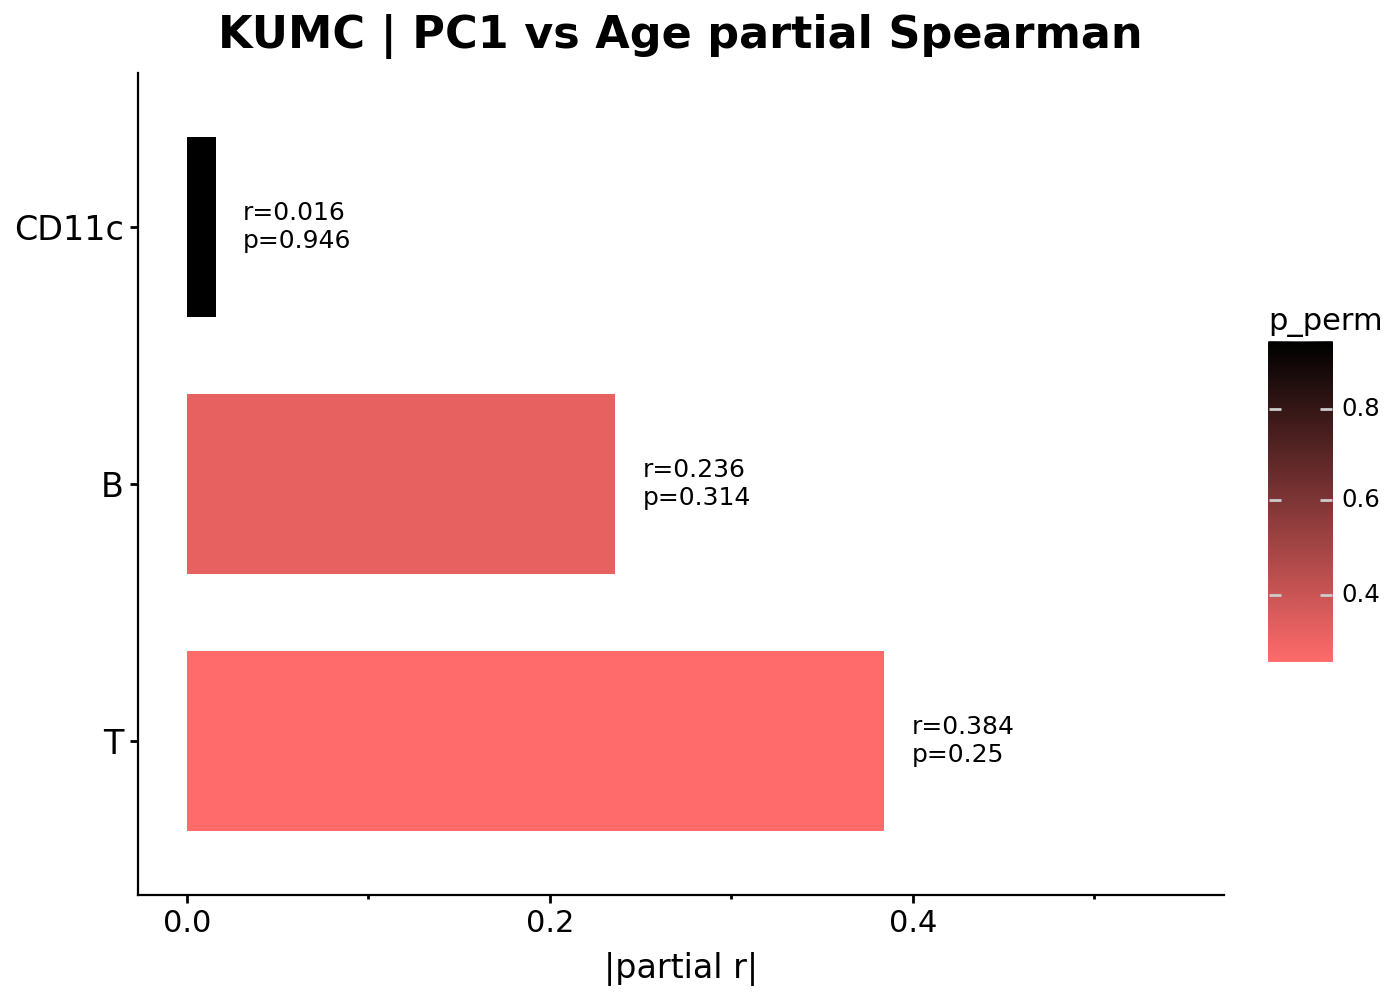

In [6]:
AGE_COL, SEX_COL, BMI_COL = "Age", "Sex_01", "BMI"
N_PERM, SEED = 2000, 123

immune_group = {
    "B": ["Transitional B", "Memory B", "Early Plasma B ", "Plasma B", "ABC"],
    "T": ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%'],
    "CD11c": ['CD11c+CD206-', 'CD11c+CD206+', 'CD11c-CD206+', 'CD11c-CD206-'],
}

def pc1_from_block(dfc, cols):
    X = dfc[cols].astype(float).values
    Xz = StandardScaler().fit_transform(X)

    pca = PCA(n_components=1, random_state=0)
    pc1 = pca.fit_transform(Xz).ravel()
    var1 = float(pca.explained_variance_ratio_[0])

    loading_df = pd.DataFrame({
        "feature": cols,
        "loading": pca.components_[0],
        "abs_loading": np.abs(pca.components_[0])
    }).sort_values("abs_loading", ascending=False).reset_index(drop=True)

    return pc1, var1, loading_df


def perm_p_partial_spearman(d, x, y, covars, n_perm=2000, seed=123):
    rng = np.random.default_rng(seed)

    out = pg.partial_corr(data=d, x=x, y=y, covar=covars, method="spearman")
    r_obs = float(out["r"].iloc[0])

    cnt = 0
    for _ in range(n_perm):
        d_perm = d.copy()
        d_perm[y] = rng.permutation(d_perm[y].values)

        r_perm = float(
            pg.partial_corr(
                data=d_perm,
                x=x,
                y=y,
                covar=covars,
                method="spearman"
            )["r"].iloc[0]
        )

        if np.isfinite(r_perm) and abs(r_perm) >= abs(r_obs):
            cnt += 1

    p = (cnt + 1) / (n_perm + 1)
    return r_obs, float(p)


def run_pc1_partial_spearman(df, dataset_name, immune_group, age_col, sex_col, bmi_col,
                             n_perm=2000, seed=123):
    rows = []
    loading_rows = []

    for gname, cols in immune_group.items():
        use_cols = cols + [age_col, sex_col, bmi_col]
        dfc = df.dropna(subset=use_cols).copy()
        n = len(dfc)

        if n < 6:
            rows.append({
                "dataset": dataset_name,
                "group": gname,
                "n": n,
                "pc1_var": np.nan,
                "partial_r": np.nan,
                "p_perm": np.nan,
                "status": "SKIP(n<6)"
            })
            continue

        pc1, var1, loading_df = pc1_from_block(dfc, cols)
        dfc["PC1"] = pc1

        tmp = dfc[[age_col, sex_col, bmi_col, "PC1"]].copy()

        r, p_perm = perm_p_partial_spearman(
            tmp,
            x="PC1",
            y=age_col,
            covars=[sex_col, bmi_col],
            n_perm=n_perm,
            seed=seed
        )

        rows.append({
            "dataset": dataset_name,
            "group": gname,
            "n": n,
            "pc1_var": var1,
            "partial_r": r,
            "p_perm": p_perm,
            "status": "OK"
        })

        loading_df["dataset"] = dataset_name
        loading_df["group"] = gname
        loading_rows.append(loading_df)

    res_df = pd.DataFrame(rows)

    res_df["q_fdr_bh"] = np.nan

    for dname in res_df["dataset"].unique():
        mask = (
            (res_df["dataset"] == dname) &
            (res_df["status"] == "OK") &
            res_df["p_perm"].notna()
        )
        pvals = res_df.loc[mask, "p_perm"].astype(float).values

        if len(pvals) >= 2:
            res_df.loc[mask, "q_fdr_bh"] = multipletests(pvals, method="fdr_bh")[1]
        elif len(pvals) == 1:
            res_df.loc[mask, "q_fdr_bh"] = pvals

    res_df = res_df.sort_values(
        ["dataset", "q_fdr_bh", "p_perm"],
        ascending=[True, True, True],
        na_position="last"
    ).reset_index(drop=True)

    if len(loading_rows) > 0:
        loadings_df = pd.concat(loading_rows, axis=0, ignore_index=True)
        loadings_df = loadings_df[["dataset", "group", "feature", "loading", "abs_loading"]]
    else:
        loadings_df = pd.DataFrame(columns=["dataset", "group", "feature", "loading", "abs_loading"])

    return res_df, loadings_df


res_df1, loadings_df1 = run_pc1_partial_spearman(
    df=df1,
    dataset_name="KUMC",
    immune_group=immune_group,
    age_col=AGE_COL,
    sex_col=SEX_COL,
    bmi_col=BMI_COL,
    n_perm=N_PERM,
    seed=SEED
)

res_df2, loadings_df2 = run_pc1_partial_spearman(
    df=df2,
    dataset_name="AMC",
    immune_group=immune_group,
    age_col=AGE_COL,
    sex_col=SEX_COL,
    bmi_col=BMI_COL,
    n_perm=N_PERM,
    seed=SEED
)


res_all_s = pd.concat([res_df1, res_df2], axis=0, ignore_index=True)
loadings_all = pd.concat([loadings_df1, loadings_df2], axis=0, ignore_index=True)

res_all_s = res_all_s.sort_values(
    ["dataset", "q_fdr_bh", "p_perm"],
    ascending=[True, True, True],
    na_position="last"
).reset_index(drop=True)

loadings_all = loadings_all.sort_values(
    ["dataset", "group", "abs_loading"],
    ascending=[True, True, False]
).reset_index(drop=True)


print("\n===== Age vs immune-cell block PC1 partial Spearman | ALL =====")
print(
    res_all_s[["dataset", "group", "n", "pc1_var", "partial_r", "p_perm", "q_fdr_bh", "status"]]
    .round(4)
    .to_string(index=False)
)

print("\n===== PC1 loadings | ALL =====")
print(
    loadings_all[["dataset", "group", "feature", "loading", "abs_loading"]]
    .round(4)
    .to_string(index=False)
)

plot_df = res_all_s.copy()
plot_df = plot_df[plot_df["status"] == "OK"].copy()
plot_df = plot_df[plot_df["group"].isin(["T", "B", "CD11c"])].copy()

plot_df = plot_df.sort_values(
    ["dataset", "q_fdr_bh", "group"],
    ascending=[True, True, True]
).reset_index(drop=True)

group_order = ["T", "B", "CD11c"]
plot_df["group"] = pd.Categorical(plot_df["group"], categories=group_order, ordered=True)
plot_df["partial_r_abs"] = plot_df["partial_r"].abs()

plot_df["label"] = (
    "r=" + plot_df["partial_r"].round(3).astype(str) +
    "\np=" + plot_df["p_perm"].round(3).astype(str)
)

plot_df["sig_star"] = np.where(plot_df["q_fdr_bh"] < 0.05, "**", "")

def make_bar_plot_plotnine(df, dataset_name):
    sub = df[df["dataset"] == dataset_name].copy()

    if len(sub) == 0:
        print(f"{dataset_name} 데이터가 없습니다.")
        return None

    sub = sub.sort_values("p_perm", ascending=True).copy()

    ordered_groups = sub["group"].astype(str).tolist()
    sub["group_plot"] = pd.Categorical(
        sub["group"].astype(str),
        categories=ordered_groups,
        ordered=True
    )

    xmax = sub["partial_r_abs"].max() + 0.16

    p = (
        ggplot(sub, aes(x="group_plot", y="partial_r_abs", fill="p_perm"))
        + geom_col(width=0.7)
        + coord_flip()
        + geom_text(
            aes(label="label"),
            nudge_y=0.015,
            size=9,
            ha="left",
            color="black"
        )
        + geom_text(
            aes(label="sig_star"),
            nudge_y=0.11,
            size=12,
            ha="left",
            color="black"
        )
        + scale_fill_gradient(
            low="#ff6b6b",
            high="#000000"
        )
        + scale_y_continuous(limits=(0, xmax))
        + labs(
            title=f"{dataset_name} | PC1 vs Age partial Spearman",
            x="",
            y="|partial r|",
            fill="p_perm"
        )
        + theme_classic()
        + theme(
            figure_size=(7, 5),
            panel_background=element_rect(fill="white", color="white"),
            plot_background=element_rect(fill="white", color="white"),
            panel_grid_major=element_blank(),
            panel_grid_minor=element_blank(),
            axis_text_y=element_text(color="black", size=12),
            axis_text_x=element_text(color="black", size=11),
            axis_title_x=element_text(color="black", size=12),
            axis_line=element_line(color="black", size=0.8),
            axis_ticks=element_line(color="black"),
            plot_title=element_text(color="black", size=16, weight="bold"),
            legend_title=element_text(color="black"),
            legend_text=element_text(color="black")
        )
    )

    return p


p_kumc = make_bar_plot_plotnine(plot_df, "KUMC")
p_amc = make_bar_plot_plotnine(plot_df, "AMC")

if p_kumc is not None:
    print(p_kumc)
    p_kumc.save("KUMC_PC1_vs_Age_partial_spearman_bar.svg", verbose=False)

if p_amc is not None:
    print(p_amc)
    p_amc.save("AMC_PC1_vs_Age_partial_spearman_bar.svg", verbose=False)


p_kumc

<ggplot: (700 x 500)>


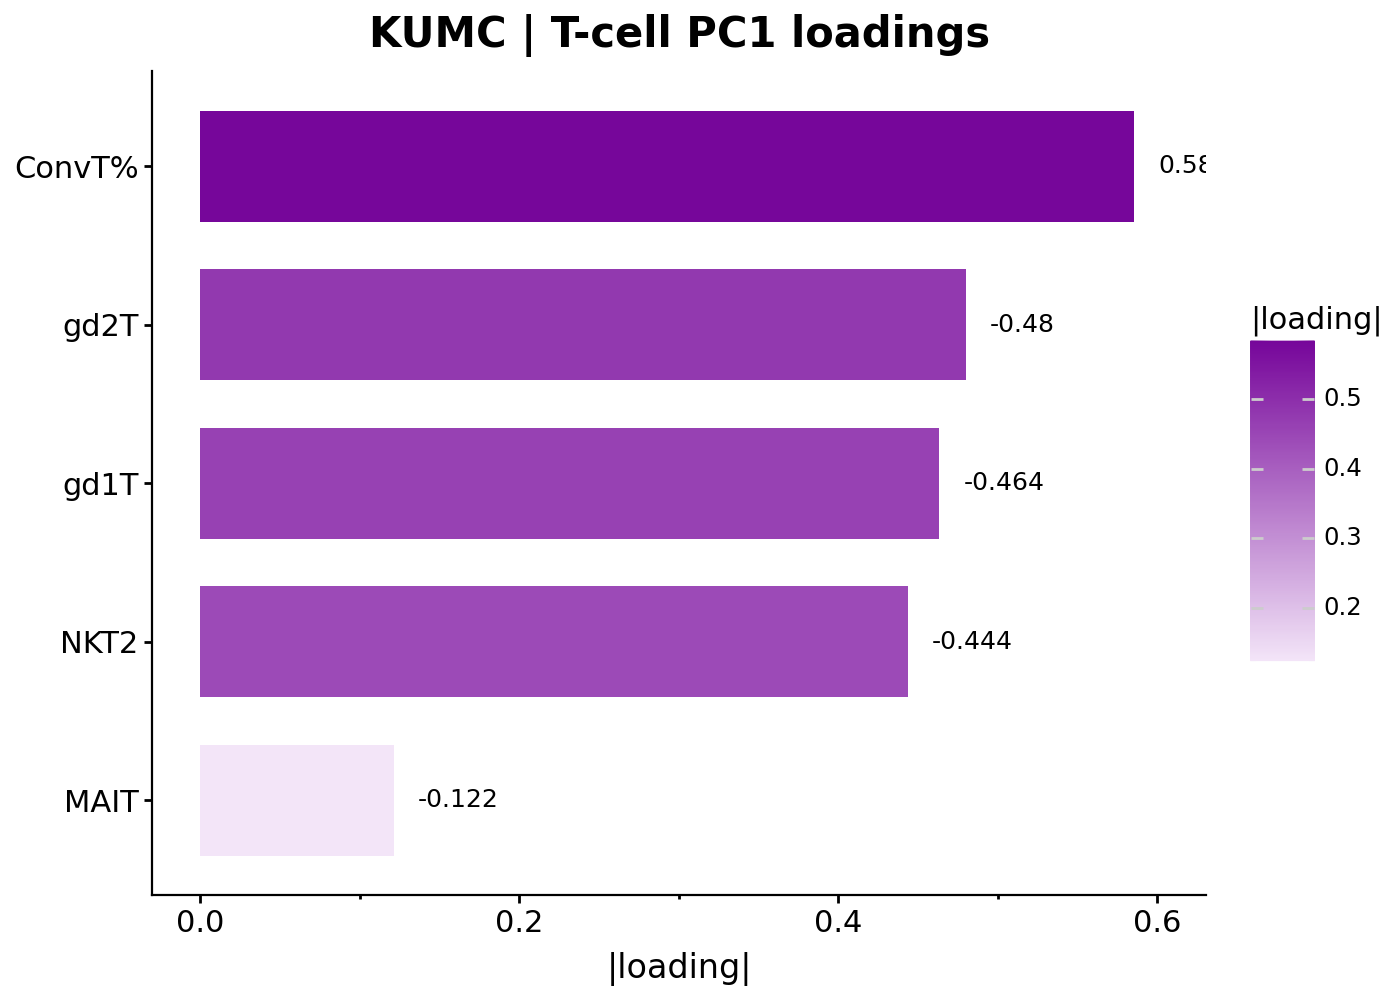

In [16]:
# Check T pc loading
t_kumc_load = (
    loadings_all[
        (loadings_all["dataset"] == "KUMC") &
        (loadings_all["group"] == "T")
    ]
    .sort_values("abs_loading", ascending=False)
    .copy()
)

t_kumc_load["feature"] = pd.Categorical(
    t_kumc_load["feature"],
    categories=t_kumc_load["feature"].tolist()[::-1],
    ordered=True
)

p_t_kumc_loading = (
    ggplot(t_kumc_load, aes(x="feature", y="abs_loading", fill="abs_loading"))
    + geom_col(width=0.7)
    + coord_flip()
    + geom_text(
        aes(label=t_kumc_load["loading"].round(3)),
        nudge_y=0.015,
        size=9,
        ha="left",
        color="black"
    )
    + scale_fill_gradient(
        low="#F3E5F8",
        high="#76069A"
    )
    + labs(
        title="KUMC | T-cell PC1 loadings",
        x="",
        y="|loading|",
        fill="|loading|"
    )
    + theme_classic()
    + theme(
        figure_size=(7, 5),
        panel_background=element_rect(fill="white", color="white"),
        plot_background=element_rect(fill="white", color="white"),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        axis_text_y=element_text(color="black", size=11),
        axis_text_x=element_text(color="black", size=11),
        axis_title_x=element_text(color="black", size=12),
        axis_line=element_line(color="black", size=0.8),
        axis_ticks=element_line(color="black"),
        plot_title=element_text(color="black", size=15, weight="bold")
    )
)

print(p_t_kumc_loading)
p_t_kumc_loading.save("KUMC_Tcell_PC1_loadings_bar.svg", verbose=False)
p_t_kumc_loading


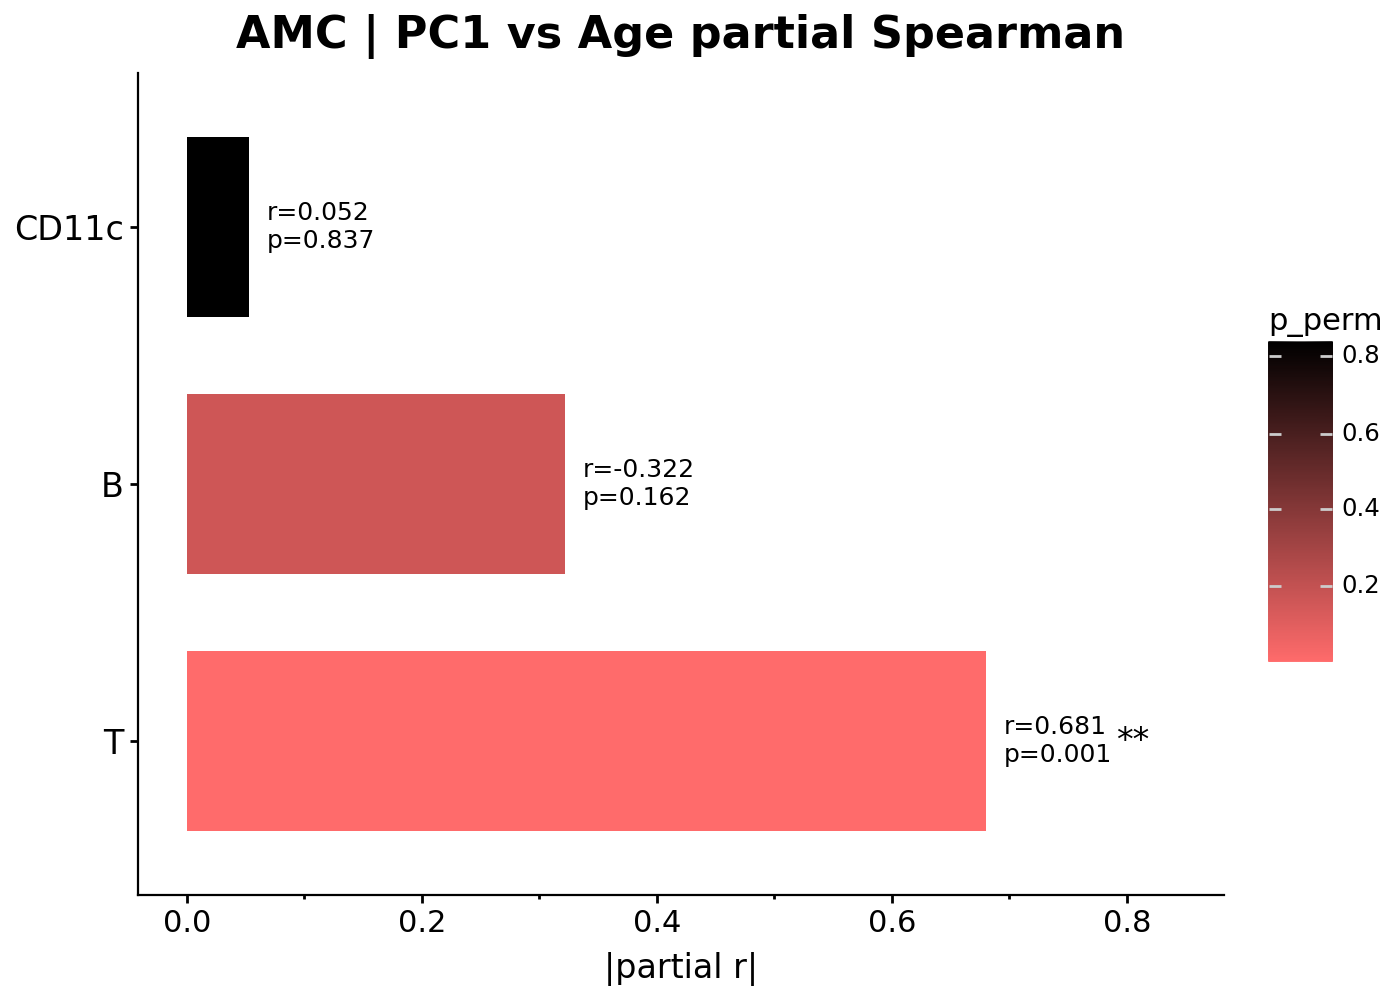

In [45]:
p_amc

<ggplot: (700 x 500)>


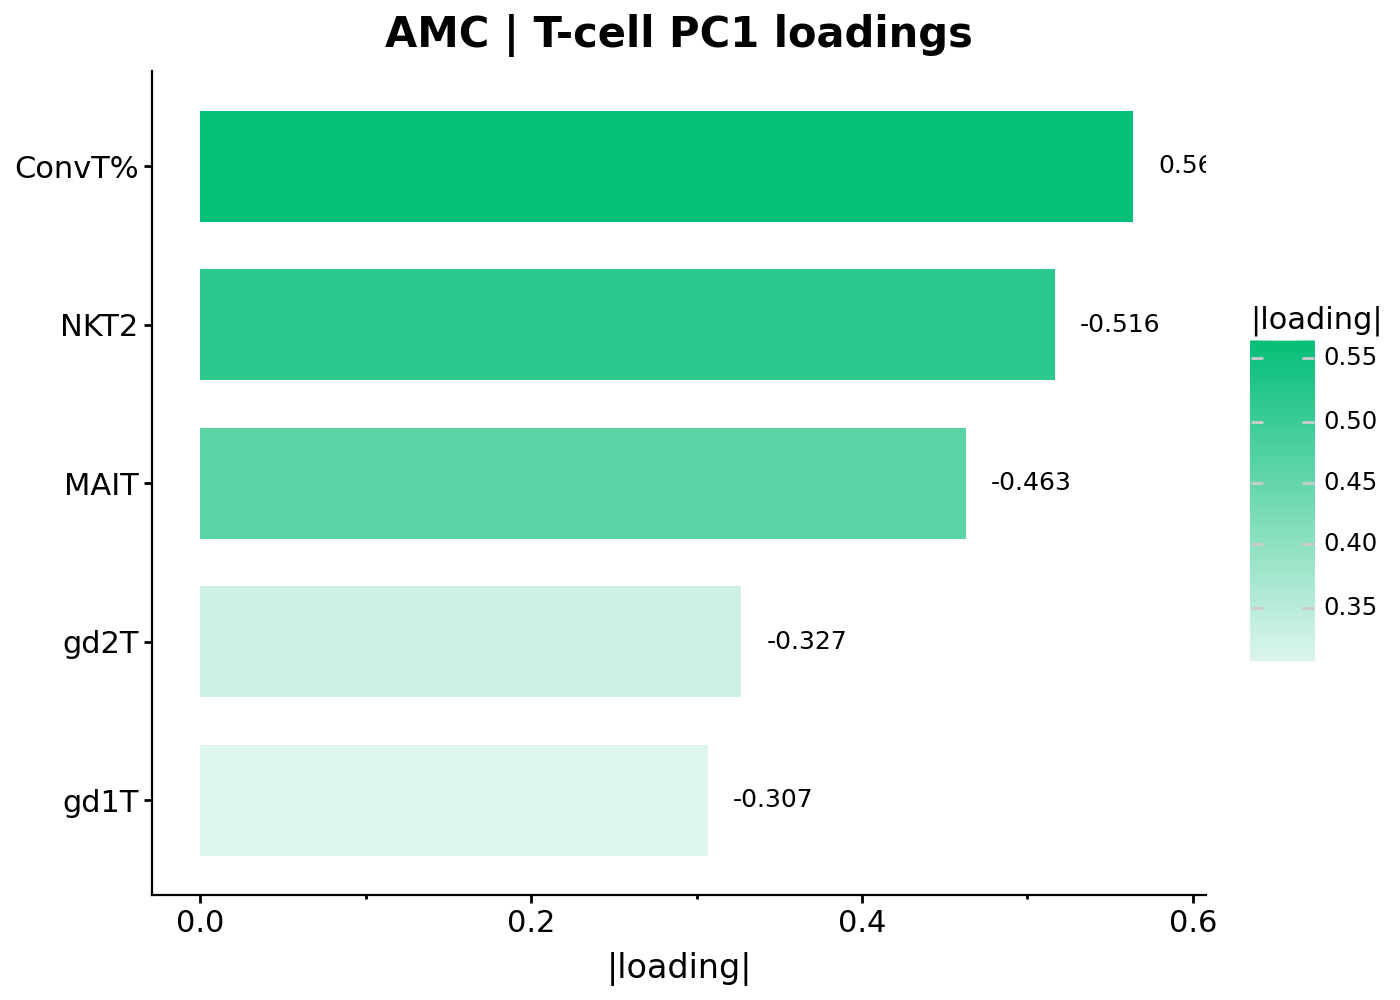

In [15]:
amc_t_load = (
    loadings_all[
        (loadings_all["dataset"] == "AMC") &
        (loadings_all["group"] == "T")
    ]
    .sort_values("abs_loading", ascending=False)
    .copy()
)

amc_t_load["feature"] = pd.Categorical(
    amc_t_load["feature"],
    categories=amc_t_load["feature"].tolist()[::-1],
    ordered=True
)

p_t_amc_loading = (
    ggplot(amc_t_load, aes(x="feature", y="abs_loading", fill="abs_loading"))
    + geom_col(width=0.7)
    + coord_flip()
    + geom_text(
        aes(label=amc_t_load["loading"].round(3)),
        nudge_y=0.015,
        size=9,
        ha="left",
        color="black"
    )
    + scale_fill_gradient(
        low="#DDF5EC",
        high="#05BE78"
    )
    + labs(
        title="AMC | T-cell PC1 loadings",
        x="",
        y="|loading|",
        fill="|loading|"
    )
    + theme_classic()
    + theme(
        figure_size=(7, 5),
        panel_background=element_rect(fill="white", color="white"),
        plot_background=element_rect(fill="white", color="white"),
        panel_grid_major=element_blank(),
        panel_grid_minor=element_blank(),
        axis_text_y=element_text(color="black", size=11),
        axis_text_x=element_text(color="black", size=11),
        axis_title_x=element_text(color="black", size=12),
        axis_line=element_line(color="black", size=0.8),
        axis_ticks=element_line(color="black"),
        plot_title=element_text(color="black", size=15, weight="bold")
    )
)

print(p_t_amc_loading)
p_t_amc_loading.save("AMC_Tcell_PC1_loadings_bar.svg", verbose=False)
p_t_amc_loading

### T cell 1:1 spearman 


=== df1 result ===
  dataset feature    method   n         r         p         q status
0     df1    gd2T  spearman  13 -0.721454  0.005376  0.026879     OK
1     df1    MAIT  spearman  13 -0.489697  0.089396  0.223489     OK
2     df1  ConvT%  spearman  13  0.429344  0.143171  0.238618     OK
3     df1    NKT2  spearman  13 -0.339590  0.256298  0.320372     OK
4     df1    gd1T  spearman  13 -0.222012  0.466006  0.466006     OK

=== df2 result ===
  dataset feature    method   n         r         p         q status
0     df2  ConvT%  spearman  22  0.672792  0.000602  0.003008     OK
1     df2    NKT2  spearman  22 -0.550967  0.007872  0.019679     OK
2     df2    gd2T  spearman  22 -0.473585  0.025990  0.043317     OK
3     df2    gd1T  spearman  22 -0.436551  0.042225  0.052781     OK
4     df2    MAIT  spearman  22 -0.301624  0.172509  0.172509     OK

=== df1 q < 0.05 only ===
  dataset feature    method   n         r         p         q status
0     df1    gd2T  spearman  13 -0.7

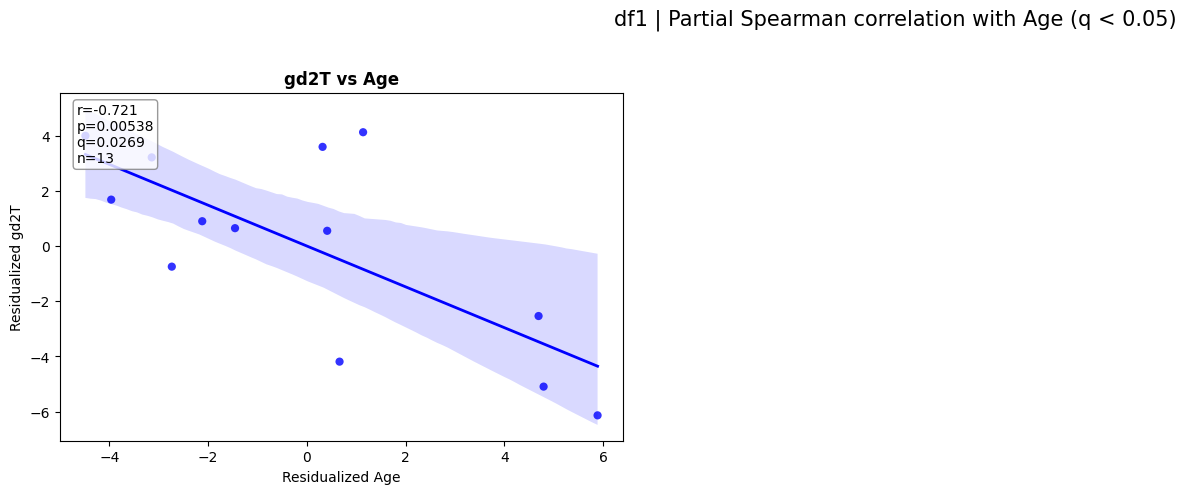

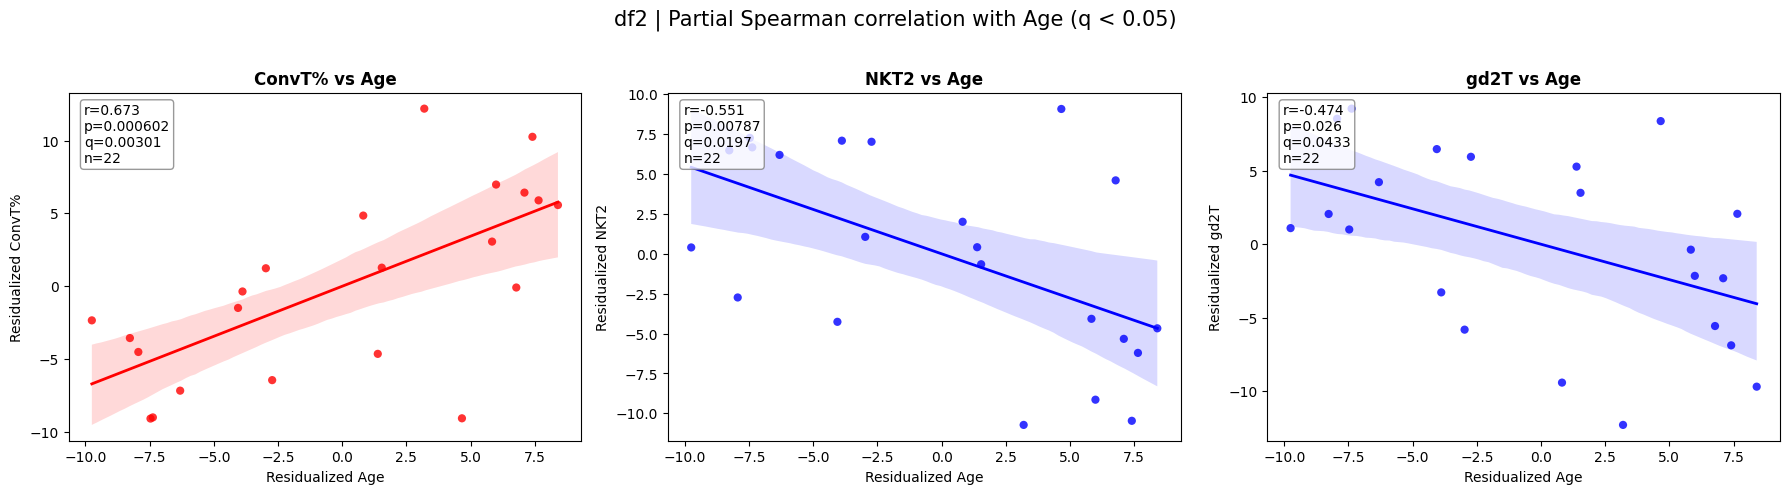

In [46]:
T_cols = ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%']
Y_COL = "Age"
COVARS = ["Sex_01", "BMI"]

SAVE_DF1 = "df1_partial_spearman_q005.svg"
SAVE_DF2 = "df2_partial_spearman_q005.svg"

def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)

    if n == 0:
        return np.array([])

    order = np.argsort(pvals)
    ranked_p = pvals[order]

    q = ranked_p * n / (np.arange(1, n + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    out = np.empty_like(q)
    out[order] = q
    return out


def residualize_vec(y, cov_df):
    X = np.column_stack([np.ones(len(cov_df)), cov_df.to_numpy(dtype=float)])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta
    return y - y_hat


def partial_corr_spearman(x, y, cov_df):
    x_rank = stats.rankdata(np.asarray(x, dtype=float))
    y_rank = stats.rankdata(np.asarray(y, dtype=float))

    cov_rank = cov_df.copy()
    for c in cov_rank.columns:
        cov_rank[c] = stats.rankdata(cov_rank[c].astype(float).to_numpy())

    x_res = residualize_vec(x_rank, cov_rank)
    y_res = residualize_vec(y_rank, cov_rank)

    r, p = stats.pearsonr(x_res, y_res)
    return {
        "r": r,
        "p": p,
        "x_res": x_res,
        "y_res": y_res
    }


def run_partial_spearman_for_dataset(df, dataset_name, x_cols, y_col, covars):
    rows = []
    detail_dict = {}

    for feat in x_cols:
        sub = df[[feat, y_col] + covars].dropna().copy()
        n = len(sub)

        if n < 4:
            rows.append({
                "dataset": dataset_name,
                "feature": feat,
                "method": "spearman",
                "n": n,
                "r": np.nan,
                "p": np.nan,
                "q": np.nan,
                "status": "SKIP(n<4)"
            })
            continue

        x = sub[feat].astype(float).to_numpy()
        y = sub[y_col].astype(float).to_numpy()
        cov = sub[covars].astype(float)

        try:
            res_s = partial_corr_spearman(x, y, cov)
            rows.append({
                "dataset": dataset_name,
                "feature": feat,
                "method": "spearman",
                "n": n,
                "r": res_s["r"],
                "p": res_s["p"],
                "q": np.nan,
                "status": "OK"
            })
            detail_dict[(dataset_name, feat, "spearman")] = res_s
        except Exception as e:
            rows.append({
                "dataset": dataset_name,
                "feature": feat,
                "method": "spearman",
                "n": n,
                "r": np.nan,
                "p": np.nan,
                "q": np.nan,
                "status": f"FAIL:{type(e).__name__}:{e}"
            })

    res = pd.DataFrame(rows)

    if "q" not in res.columns:
        res["q"] = np.nan

    mask = (res["status"] == "OK") & (res["method"] == "spearman")
    if mask.sum() > 0:
        res.loc[mask, "q"] = bh_fdr(res.loc[mask, "p"].values)

    res = res.sort_values(
        ["dataset", "p"],
        ascending=[True, True],
        na_position="last"
    ).reset_index(drop=True)

    return res, detail_dict


def plot_partial_spearman_panels(detail_dict, res_df, dataset_name, save_path, ncols=3, q_thresh=0.05):
    if "q" not in res_df.columns:
        print(f"'q' column not found in res_df for {dataset_name}")
        return

    sub_res = res_df[
        (res_df["dataset"] == dataset_name) &
        (res_df["method"] == "spearman") &
        (res_df["status"] == "OK") &
        (res_df["q"] < q_thresh)
    ].copy()

    if len(sub_res) == 0:
        print(f"No q<{q_thresh} results to plot for {dataset_name}")
        return

    features = sub_res["feature"].tolist()
    n_panels = len(features)
    nrows = int(np.ceil(n_panels / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.8 * nrows))
    axes = np.array(axes).reshape(-1)

    q_map = {r["feature"]: r["q"] for _, r in sub_res.iterrows()}
    p_map = {r["feature"]: r["p"] for _, r in sub_res.iterrows()}
    r_map = {r["feature"]: r["r"] for _, r in sub_res.iterrows()}
    n_map = {r["feature"]: r["n"] for _, r in sub_res.iterrows()}

    for i, feat in enumerate(features):
        ax = axes[i]
        res = detail_dict[(dataset_name, feat, "spearman")]

        plot_df = pd.DataFrame({
            "x_res": res["x_res"],
            "y_res": res["y_res"]
        })

        r_val = r_map.get(feat, np.nan)
        color = "blue" if r_val < 0 else "red"

        sns.regplot(
            data=plot_df,
            x="y_res",
            y="x_res",
            ax=ax,
            color=color,
            scatter_kws={"s": 35, "alpha": 0.8, "edgecolor": "none"},
            line_kws={"lw": 2},
            ci=95
        )

        p = p_map.get(feat, np.nan)
        q = q_map.get(feat, np.nan)
        n = n_map.get(feat, len(plot_df))

        ax.set_title(f"{feat} vs {Y_COL}", fontweight="bold")
        ax.set_xlabel(f"Residualized {Y_COL}")
        ax.set_ylabel(f"Residualized {feat}")

        ax.text(
            0.03, 0.97,
            f"r={r_val:.3f}\np={p:.3g}\nq={q:.3g}\nn={n}",
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=10,
            bbox=dict(boxstyle="round,pad=0.25", fc="white", ec="gray", alpha=0.8)
        )

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(
        f"{dataset_name} | Partial Spearman correlation with {Y_COL} (q < {q_thresh})",
        fontsize=15, y=1.02
    )
    plt.tight_layout()

    fig.savefig(save_path, format="svg", bbox_inches="tight")
    plt.show()


res_df1, detail_df1 = run_partial_spearman_for_dataset(
    df1,
    dataset_name="df1",
    x_cols=T_cols,
    y_col=Y_COL,
    covars=COVARS
)

res_df2, detail_df2 = run_partial_spearman_for_dataset(
    df2,
    dataset_name="df2",
    x_cols=T_cols,
    y_col=Y_COL,
    covars=COVARS
)

print("\n=== df1 result ===")
print(res_df1)

print("\n=== df2 result ===")
print(res_df2)

print("\n=== df1 q < 0.05 only ===")
print(res_df1[(res_df1["status"] == "OK") & (res_df1["q"] < 0.05)].copy())

print("\n=== df2 q < 0.05 only ===")
print(res_df2[(res_df2["status"] == "OK") & (res_df2["q"] < 0.05)].copy())

plot_partial_spearman_panels(
    detail_dict=detail_df1,
    res_df=res_df1,
    dataset_name="df1",
    save_path=SAVE_DF1,
    q_thresh=0.05
)

plot_partial_spearman_panels(
    detail_dict=detail_df2,
    res_df=res_df2,
    dataset_name="df2",
    save_path=SAVE_DF2,
    q_thresh=0.05
)

### Heatmap - changing covariate


[T_pc1]
  explained variance ratio = 0.5168
  n_valid = 13
  loadings:
    NKT2: 0.4437
    MAIT: 0.1215
    gd1T: 0.4635
    gd2T: 0.4802
    ConvT%: -0.5855

[B_pc1]
  explained variance ratio = 0.6334
  n_valid = 22
  loadings:
    Transitional B: -0.5489
    Memory B: 0.3478
    Early Plasma B : 0.4271
    Plasma B: 0.4698
    ABC: 0.4179

[CD11c_pc1]
  explained variance ratio = 0.5005
  n_valid = 22
  loadings:
    CD11c+CD206-: 0.6610
    CD11c+CD206+: -0.6752
    CD11c-CD206+: -0.1690
    CD11c-CD206-: 0.2804

[T_pc1]
  explained variance ratio = 0.6073
  n_valid = 22
  loadings:
    NKT2: 0.5165
    MAIT: 0.4626
    gd1T: 0.3069
    gd2T: 0.3272
    ConvT%: -0.5639

[B_pc1]
  explained variance ratio = 0.6107
  n_valid = 22
  loadings:
    Transitional B: -0.5694
    Memory B: 0.2636
    Early Plasma B : 0.4743
    Plasma B: 0.4497
    ABC: 0.4232

[CD11c_pc1]
  explained variance ratio = 0.6616
  n_valid = 22
  loadings:
    CD11c+CD206-: -0.5983
    CD11c+CD206+: 0.4643
   

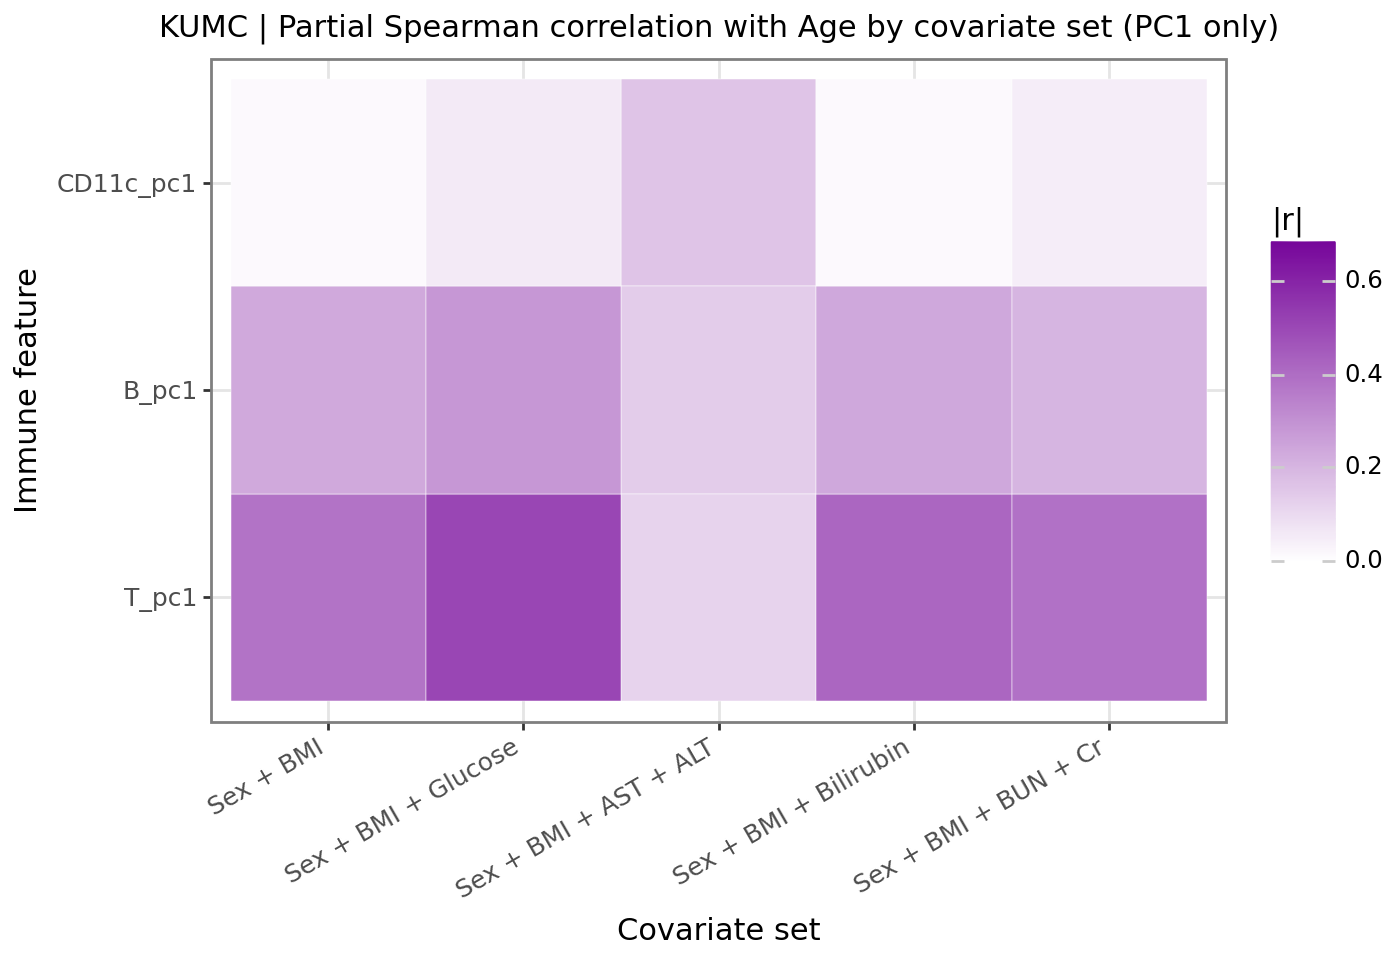

In [ ]:
KUMC = df1.copy()
AMC  = df2.copy()

PC_GROUPS = {
    "T_pc1": ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%'],
    "B_pc1": ["Transitional B", "Memory B", "Early Plasma B ", "Plasma B", "ABC"],
    "CD11c_pc1": ['CD11c+CD206-', 'CD11c+CD206+', 'CD11c-CD206+', 'CD11c-CD206-']
}

TARGET_VARS = [
    "T_pc1", "B_pc1", "CD11c_pc1",
    'CD4grzk', 'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK'
]

PC1_VARS = ["T_pc1", "B_pc1", "CD11c_pc1"]
GRZK_VARS = ['CD4grzk', 'CD8grzk', 'MAITgrzK', 'GD1TgrzK', 'GD2TgrzK']

Y_COL = "Age"

COVAR_SETS = {
    "covset1_SexBMI": ['Sex_01', 'BMI'],
    "covset2_SexBMI_ASTALT": ['Sex_01', 'BMI', 'AST', 'ALT'],
    "covset3_SexBMI_Glucose": ['Sex_01', 'BMI', 'Gulucose'], 
    "covset4_SexBMI_Bilirubin": ['Sex_01', 'BMI', 'Bilirubin'],
    "covset5_SexBMI_BUNCr": ['Sex_01', 'BMI', 'BUN', 'Cr']
}

def bh_fdr(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)

    if n == 0:
        return np.array([])

    order = np.argsort(pvals)
    ranked_p = pvals[order]

    q = ranked_p * n / (np.arange(1, n + 1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.clip(q, 0, 1)

    out = np.empty_like(q)
    out[order] = q
    return out


def residualize_vec(y, cov_df):
    X = np.column_stack([np.ones(len(cov_df)), cov_df.to_numpy(dtype=float)])
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    y_hat = X @ beta
    return y - y_hat


def partial_corr_pearson(x, y, cov_df):
    x_res = residualize_vec(np.asarray(x, dtype=float), cov_df)
    y_res = residualize_vec(np.asarray(y, dtype=float), cov_df)
    r, p = stats.pearsonr(x_res, y_res)
    return {"r": r, "p": p, "x_res": x_res, "y_res": y_res}


def partial_corr_spearman(x, y, cov_df):
    x_rank = stats.rankdata(np.asarray(x, dtype=float))
    y_rank = stats.rankdata(np.asarray(y, dtype=float))

    cov_rank = cov_df.copy()
    for c in cov_rank.columns:
        cov_rank[c] = stats.rankdata(cov_rank[c].astype(float).to_numpy())

    x_res = residualize_vec(x_rank, cov_rank)
    y_res = residualize_vec(y_rank, cov_rank)
    r, p = stats.pearsonr(x_res, y_res)
    return {"r": r, "p": p, "x_res": x_res, "y_res": y_res}

def add_group_pc1(df, pc_groups, standardize=True):
    out = df.copy()

    for new_col, cols in pc_groups.items():
        missing_cols = [c for c in cols if c not in out.columns]
        if len(missing_cols) > 0:
            raise ValueError(f"{new_col} 생성 불가. 없는 컬럼: {missing_cols}")

        sub = out[cols].copy()
        valid_idx = sub.dropna().index

        out[new_col] = np.nan

        if len(valid_idx) < 2:
            print(f"[WARN] {new_col}: 유효 샘플 수 부족 ({len(valid_idx)})")
            continue

        X = sub.loc[valid_idx].astype(float).to_numpy()

        if standardize:
            scaler = StandardScaler()
            X = scaler.fit_transform(X)

        pca = PCA(n_components=1)
        pc1_scores = pca.fit_transform(X).flatten()

        loadings = pca.components_[0]
        if np.sum(loadings) < 0:
            pc1_scores = -pc1_scores
            loadings = -loadings

        out.loc[valid_idx, new_col] = pc1_scores

        print(f"\n[{new_col}]")
        print(f"  explained variance ratio = {pca.explained_variance_ratio_[0]:.4f}")
        print(f"  n_valid = {len(valid_idx)}")
        print("  loadings:")
        for c, l in zip(cols, loadings):
            print(f"    {c}: {l:.4f}")

    return out

def run_partial_corr_multi_covsets(df, dataset_name, y_col, target_vars, covar_sets):
    rows = []
    detail_dict = {}

    for covset_name, covars in covar_sets.items():
        for feat in target_vars:
            needed = [feat, y_col] + covars
            missing_cols = [c for c in needed if c not in df.columns]

            if len(missing_cols) > 0:
                rows.append({
                    "dataset": dataset_name,
                    "covset": covset_name,
                    "feature": feat,
                    "feature_group": "pc1" if feat in PC1_VARS else "grzk",
                    "method": "pearson",
                    "n": np.nan,
                    "r": np.nan,
                    "p": np.nan,
                    "q": np.nan,
                    "status": f"FAIL:missing_cols:{missing_cols}"
                })
                rows.append({
                    "dataset": dataset_name,
                    "covset": covset_name,
                    "feature": feat,
                    "feature_group": "pc1" if feat in PC1_VARS else "grzk",
                    "method": "spearman",
                    "n": np.nan,
                    "r": np.nan,
                    "p": np.nan,
                    "q": np.nan,
                    "status": f"FAIL:missing_cols:{missing_cols}"
                })
                continue

            sub = df[needed].dropna().copy()
            n = len(sub)

            if n < (len(covars) + 4):
                rows.append({
                    "dataset": dataset_name,
                    "covset": covset_name,
                    "feature": feat,
                    "feature_group": "pc1" if feat in PC1_VARS else "grzk",
                    "method": "pearson",
                    "n": n,
                    "r": np.nan,
                    "p": np.nan,
                    "q": np.nan,
                    "status": f"SKIP(n<{len(covars)+4})"
                })
                rows.append({
                    "dataset": dataset_name,
                    "covset": covset_name,
                    "feature": feat,
                    "feature_group": "pc1" if feat in PC1_VARS else "grzk",
                    "method": "spearman",
                    "n": n,
                    "r": np.nan,
                    "p": np.nan,
                    "q": np.nan,
                    "status": f"SKIP(n<{len(covars)+4})"
                })
                continue

            x = sub[feat].astype(float).to_numpy()
            y = sub[y_col].astype(float).to_numpy()
            cov = sub[covars].astype(float)

            try:
                res_p = partial_corr_pearson(x, y, cov)
                rows.append({
                    "dataset": dataset_name,
                    "covset": covset_name,
                    "feature": feat,
                    "feature_group": "pc1" if feat in PC1_VARS else "grzk",
                    "method": "pearson",
                    "n": n,
                    "r": res_p["r"],
                    "p": res_p["p"],
                    "q": np.nan,
                    "status": "OK"
                })
                detail_dict[(dataset_name, covset_name, feat, "pearson")] = res_p
            except Exception as e:
                rows.append({
                    "dataset": dataset_name,
                    "covset": covset_name,
                    "feature": feat,
                    "feature_group": "pc1" if feat in PC1_VARS else "grzk",
                    "method": "pearson",
                    "n": n,
                    "r": np.nan,
                    "p": np.nan,
                    "q": np.nan,
                    "status": f"FAIL:{type(e).__name__}:{e}"
                })

            try:
                res_s = partial_corr_spearman(x, y, cov)
                rows.append({
                    "dataset": dataset_name,
                    "covset": covset_name,
                    "feature": feat,
                    "feature_group": "pc1" if feat in PC1_VARS else "grzk",
                    "method": "spearman",
                    "n": n,
                    "r": res_s["r"],
                    "p": res_s["p"],
                    "q": np.nan,
                    "status": "OK"
                })
                detail_dict[(dataset_name, covset_name, feat, "spearman")] = res_s
            except Exception as e:
                rows.append({
                    "dataset": dataset_name,
                    "covset": covset_name,
                    "feature": feat,
                    "feature_group": "pc1" if feat in PC1_VARS else "grzk",
                    "method": "spearman",
                    "n": n,
                    "r": np.nan,
                    "p": np.nan,
                    "q": np.nan,
                    "status": f"FAIL:{type(e).__name__}:{e}"
                })

    res = pd.DataFrame(rows)

    for dataset_name in res["dataset"].dropna().unique():
        for covset_name in res["covset"].dropna().unique():
            for method in ["pearson", "spearman"]:
                for feature_group in ["pc1", "grzk"]:
                    mask = (
                        (res["dataset"] == dataset_name) &
                        (res["covset"] == covset_name) &
                        (res["method"] == method) &
                        (res["feature_group"] == feature_group) &
                        (res["status"] == "OK")
                    )
                    if mask.sum() > 0:
                        res.loc[mask, "q"] = bh_fdr(res.loc[mask, "p"].values)

    res = res.sort_values(
        ["dataset", "covset", "feature_group", "method", "p"],
        ascending=[True, True, True, True, True],
        na_position="last"
    ).reset_index(drop=True)

    return res, detail_dict

KUMC_pc = add_group_pc1(KUMC, PC_GROUPS, standardize=True)
AMC_pc  = add_group_pc1(AMC,  PC_GROUPS, standardize=True)

res_kumc, detail_kumc = run_partial_corr_multi_covsets(
    df=KUMC_pc,
    dataset_name="KUMC",
    y_col=Y_COL,
    target_vars=TARGET_VARS,
    covar_sets=COVAR_SETS
)

res_amc, detail_amc = run_partial_corr_multi_covsets(
    df=AMC_pc,
    dataset_name="AMC",
    y_col=Y_COL,
    target_vars=TARGET_VARS,
    covar_sets=COVAR_SETS
)

res_all = pd.concat([res_kumc, res_amc], ignore_index=True)

print("\n=== KUMC result ===")
print(res_kumc)

print("\n=== AMC result ===")
print(res_amc)

print("\n=== ALL result ===")
print(res_all)

sig_res = res_all[(res_all["status"] == "OK") & (res_all["q"] < 0.05)].copy()

print("\n=== q < 0.05 only ===")
print(sig_res)

plot_df = (
    res_all.copy()
    .query("status == 'OK' and method == 'spearman'")
    .dropna(subset=["r", "p", "q"])
    .copy()
)

label_map = {
    "covset1_SexBMI": "Sex + BMI",
    "covset2_SexBMI_ASTALT": "Sex + BMI + AST + ALT",
    "covset3_SexBMI_Glucose": "Sex + BMI + Glucose",
    "covset4_SexBMI_Bilirubin": "Sex + BMI + Bilirubin",
    "covset5_SexBMI_BUNCr": "Sex + BMI + BUN + Cr",
}

plot_df["model"] = plot_df["covset"].map(label_map)

new_order = [
    "Sex + BMI",
    "Sex + BMI + Glucose",
    "Sex + BMI + AST + ALT",
    "Sex + BMI + Bilirubin",
    "Sex + BMI + BUN + Cr",
]
plot_df["model"] = pd.Categorical(plot_df["model"], categories=new_order, ordered=True)
plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=["KUMC", "AMC"], ordered=True)

# =========================
# PC1 heatmap  (ABS(r), dataset-specific gradient)
# =========================
plot_df_pc1 = plot_df[plot_df["feature_group"] == "pc1"].copy()
plot_df_pc1["feature"] = pd.Categorical(plot_df_pc1["feature"], categories=PC1_VARS, ordered=True)
plot_df_pc1["r_abs"] = plot_df_pc1["r"].abs()

# KUMC / AMC 분리
plot_df_pc1_kumc = plot_df_pc1[plot_df_pc1["dataset"] == "KUMC"].copy()
plot_df_pc1_amc  = plot_df_pc1[plot_df_pc1["dataset"] == "AMC"].copy()

sig_df_pc1_kumc = plot_df_pc1_kumc[plot_df_pc1_kumc["q"] < 0.05].copy()
mid_df_pc1_kumc = plot_df_pc1_kumc[
    (plot_df_pc1_kumc["q"] >= 0.05) & (plot_df_pc1_kumc["q"] < 0.1)
].copy()

sig_df_pc1_amc = plot_df_pc1_amc[plot_df_pc1_amc["q"] < 0.05].copy()
mid_df_pc1_amc = plot_df_pc1_amc[
    (plot_df_pc1_amc["q"] >= 0.05) & (plot_df_pc1_amc["q"] < 0.1)
].copy()

pc1_fill_max = plot_df_pc1["r_abs"].max()

p_heat_pc1_kumc = (
    ggplot(plot_df_pc1_kumc, aes(x="model", y="feature", fill="r_abs"))
    + geom_tile(color="white")
    + geom_text(
        mid_df_pc1_kumc,
        aes(x="model", y="feature", label="'*'"),
        inherit_aes=False,
        size=14,
        alpha=0.85
    )
    + geom_text(
        sig_df_pc1_kumc,
        aes(x="model", y="feature", label="'**'"),
        inherit_aes=False,
        size=10,
        alpha=0.95
    )
    + scale_fill_gradient(
        low="white",
        high="#76069A",
        limits=(0, pc1_fill_max)
    )
    + labs(
        title="KUMC | Partial Spearman correlation with Age by covariate set (PC1 only)",
        x="Covariate set",
        y="Immune feature",
        fill="|r|"
    )
    + theme_bw()
    + theme(
        figure_size=(7, 4.8),
        axis_text_y=element_text(size=9),
        axis_text_x=element_text(size=9, angle=30, ha="right"),
        plot_title=element_text(size=11)
    )
)

p_heat_pc1_amc = (
    ggplot(plot_df_pc1_amc, aes(x="model", y="feature", fill="r_abs"))
    + geom_tile(color="white")
    + geom_text(
        mid_df_pc1_amc,
        aes(x="model", y="feature", label="'*'"),
        inherit_aes=False,
        size=14,
        alpha=0.85
    )
    + geom_text(
        sig_df_pc1_amc,
        aes(x="model", y="feature", label="'**'"),
        inherit_aes=False,
        size=10,
        alpha=0.95
    )
    + scale_fill_gradient(
        low="white",
        high="#05BE78",
        limits=(0, pc1_fill_max)
    )
    + labs(
        title="AMC | Partial Spearman correlation with Age by covariate set (PC1 only)",
        x="Covariate set",
        y="Immune feature",
        fill="|r|"
    )
    + theme_bw()
    + theme(
        figure_size=(7, 4.8),
        axis_text_y=element_text(size=9),
        axis_text_x=element_text(size=9, angle=30, ha="right"),
        plot_title=element_text(size=11)
    )
)

p_heat_pc1_kumc.save("heatmap_by_covset_pc1_q_group_KUMC_absr.svg", verbose=False)
p_heat_pc1_amc.save("heatmap_by_covset_pc1_q_group_AMC_absr.svg", verbose=False)

p_heat_pc1_kumc
p_heat_pc1_amc
# =========================
# grzK heatmap
# =========================
plot_df_grzk = plot_df[plot_df["feature_group"] == "grzk"].copy()
plot_df_grzk["feature"] = pd.Categorical(plot_df_grzk["feature"], categories=GRZK_VARS, ordered=True)

sig_df_grzk = plot_df_grzk[plot_df_grzk["q"] < 0.05].copy()
mid_df_grzk = plot_df_grzk[(plot_df_grzk["q"] >= 0.05) & (plot_df_grzk["q"] < 0.1)].copy()

p_heat_grzk = (
    ggplot(plot_df_grzk, aes(x="model", y="feature", fill="r"))
    + geom_tile(color="white")
    + geom_text(
        mid_df_grzk,
        aes(x="model", y="feature", label="'*'"),
        inherit_aes=False,
        size=14,
        alpha=0.85
    )
    + geom_text(
        sig_df_grzk,
        aes(x="model", y="feature", label="'**'"),
        inherit_aes=False,
        size=10,
        alpha=0.95
    )
    + facet_wrap("~dataset", ncol=2)
    + scale_fill_gradient2(low="#00BFC4", mid="white", high="#F8766D")
    + labs(
        title="Partial Spearman correlation with Age by covariate set (grzK only)",
        x="Covariate set",
        y="Immune feature",
        fill="r"
    )
    + theme_bw()
    + theme(
        figure_size=(14, 6),
        axis_text_y=element_text(size=9),
        axis_text_x=element_text(size=9, angle=30, ha="right"),
        strip_text=element_text(size=11)
    )
)

p_heat_grzk.save("heatmap_by_covset_grzk_q_group.svg", verbose=False)

p_heat_pc1_kumc

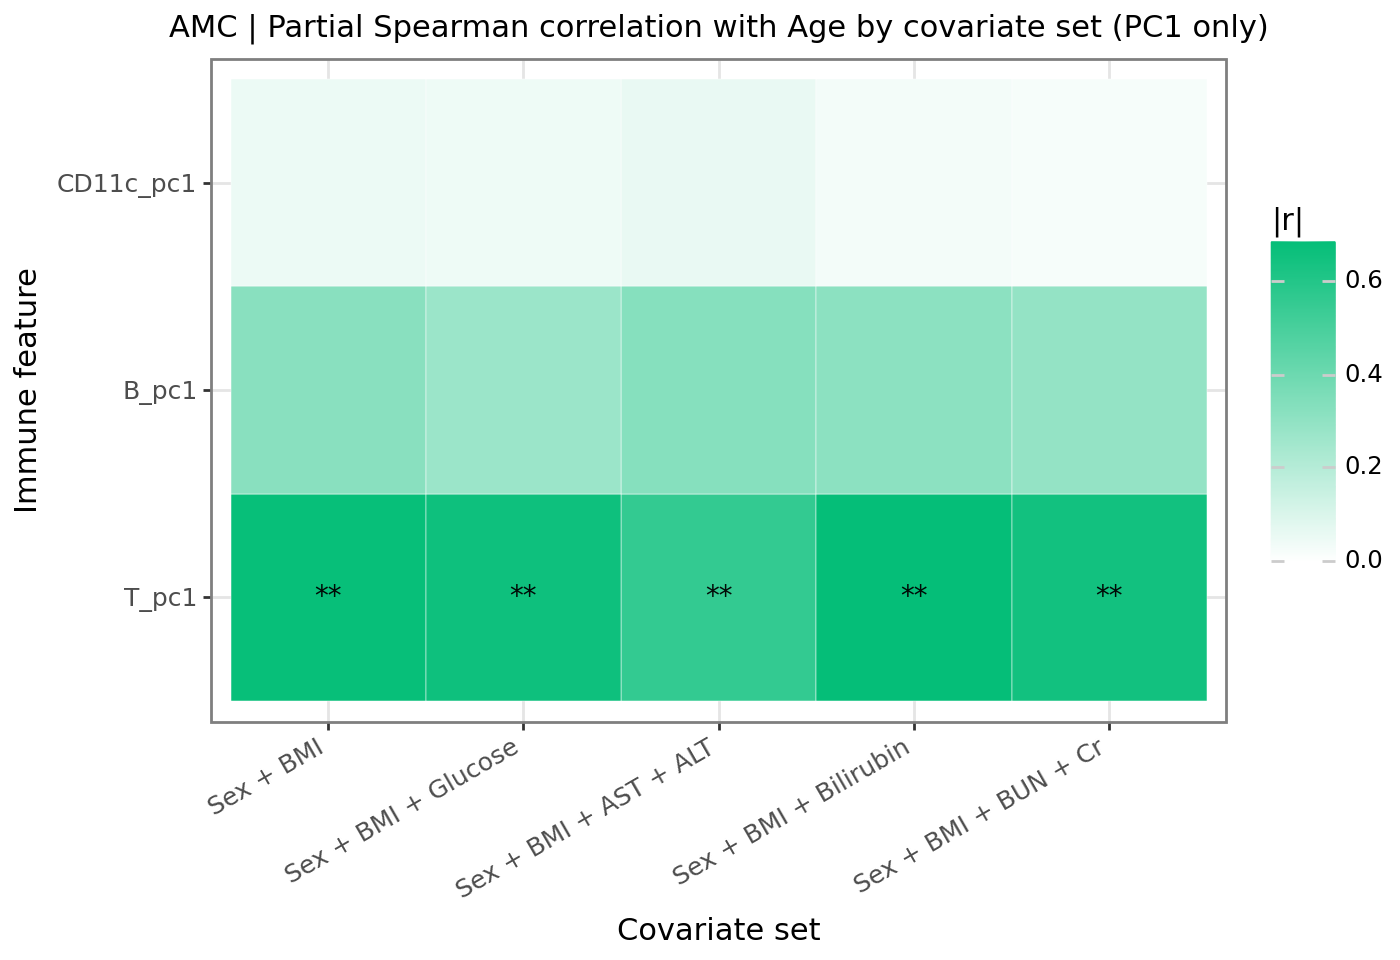

In [19]:
p_heat_pc1_amc

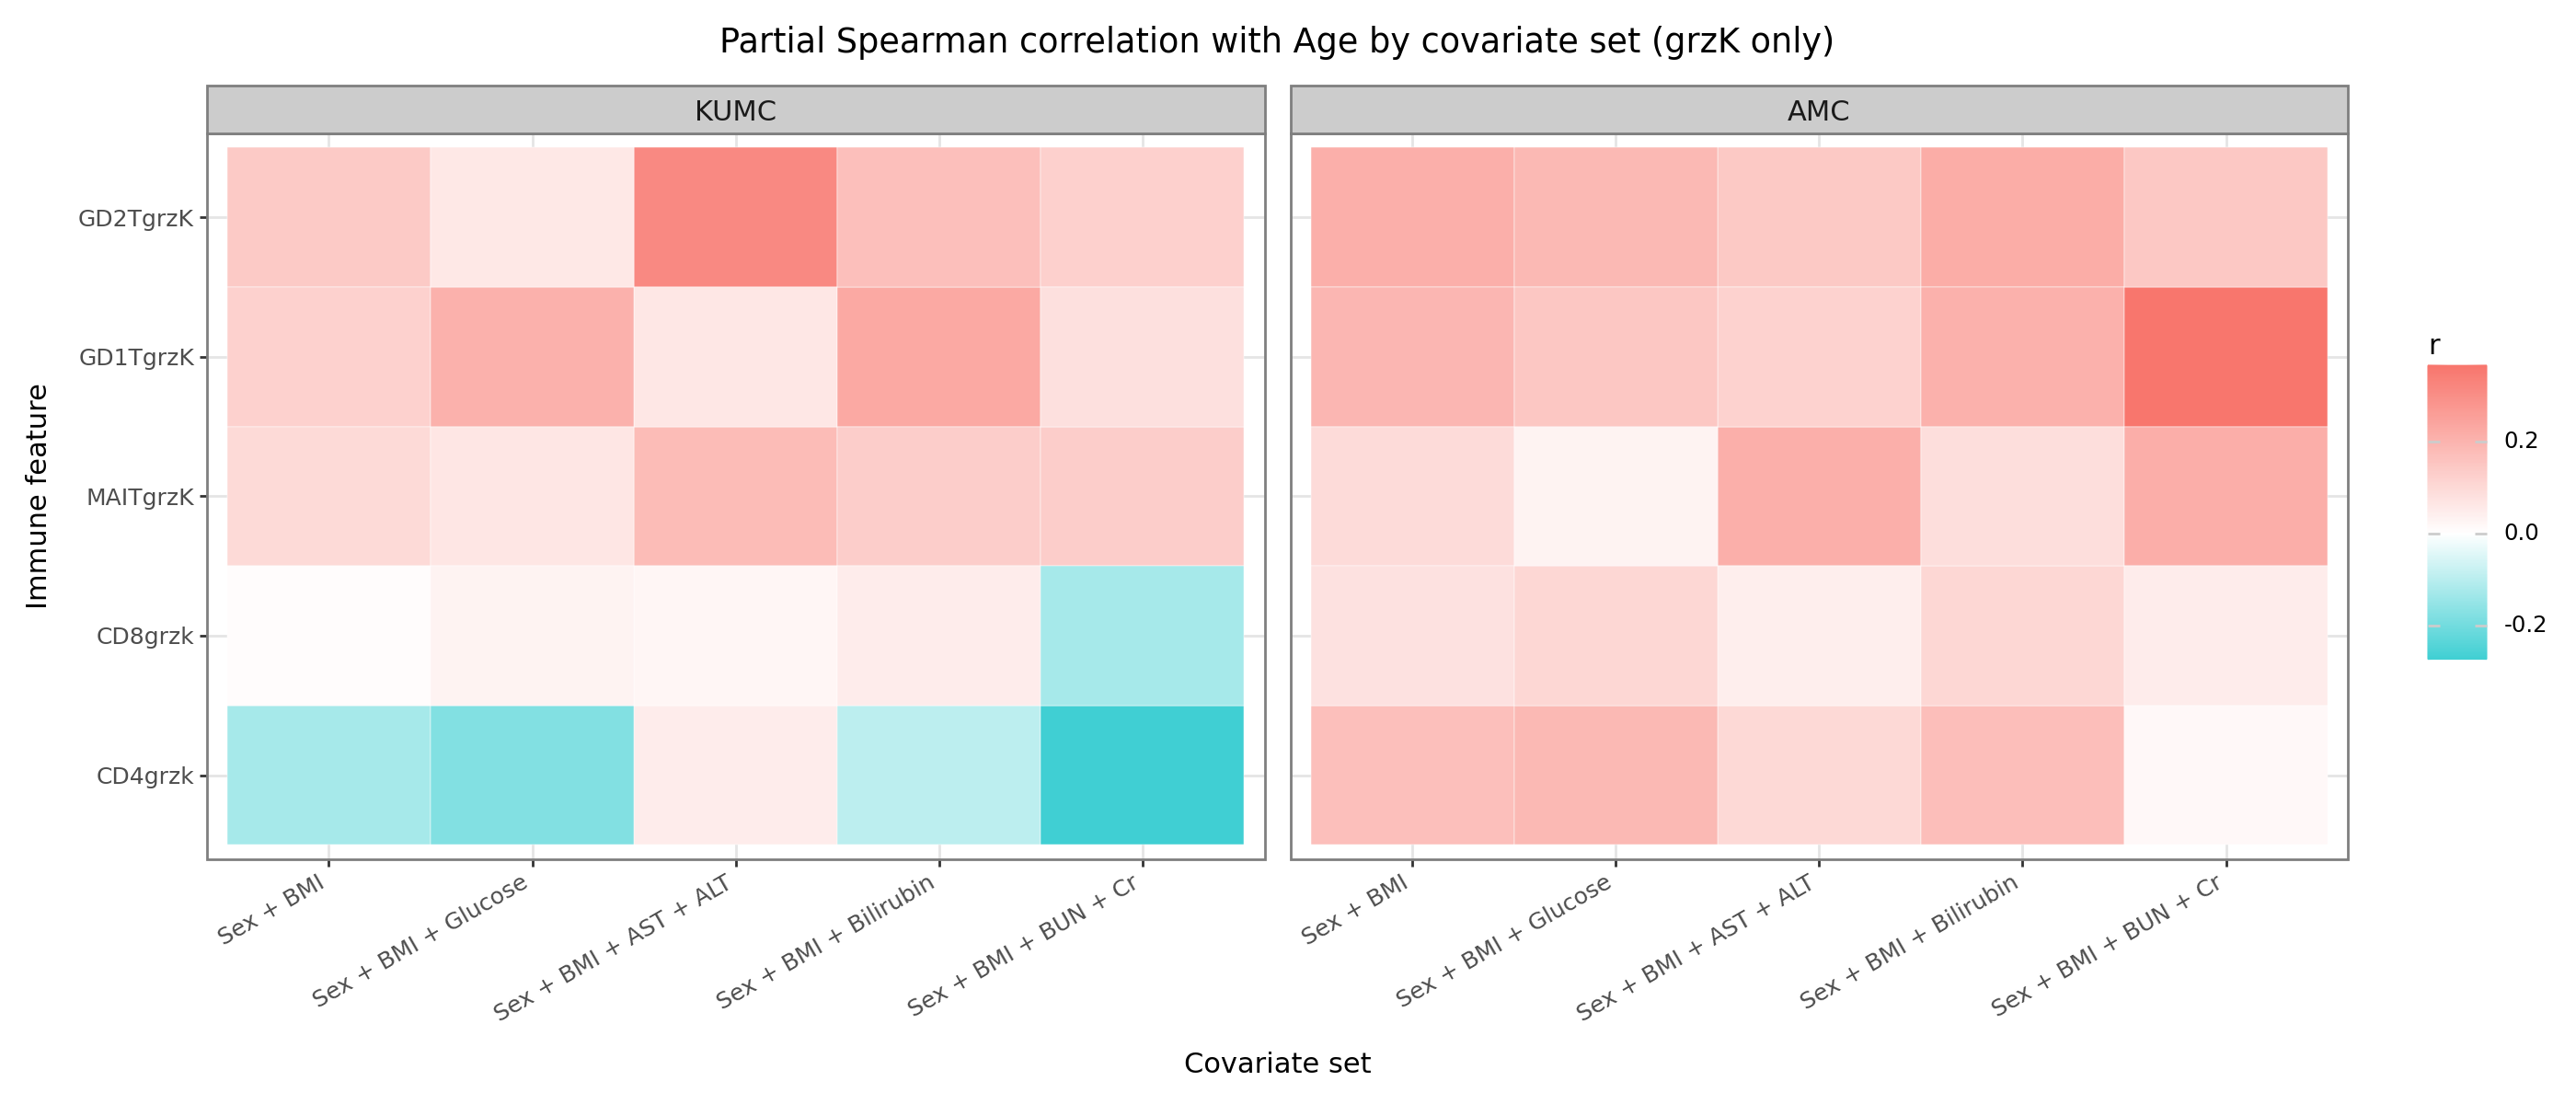

In [20]:
p_heat_grzk

# Task2

### PC analysis

In [48]:
COVARS = ["Age", "Sex_01"]
MIN_N = 10

X_groups = {
    "PAN%": ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T'],
    "B": ["Transitional B", "Memory B", "Early Plasma B ", "Plasma B", "ABC"],
    "T": ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%'],
    "ConvT": ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg'],
    "CD11c": ['CD11c+CD206-', 'CD11c+CD206+', 'CD11c-CD206+', 'CD11c-CD206-'],
}

Z_groups = {
    "Metabolic1": ['BMI', 'Cholesterol', 'Gulucose'],
    "Liver1": ['AST', 'ALT', 'ALP', 'Bilirubin', 'Albumin'],
    "Kidney1": ['BUN', 'Cr'],
}

def run_group_pca(df, group_dict, prefix, min_n=5):
    score_df = pd.DataFrame(index=df.index)
    meta_rows = []
    loading_dict = {}

    for gname, cols in group_dict.items():
        cols_exist = [c for c in cols if c in df.columns]

        if len(cols_exist) < 2:
            print(f"[SKIP] {gname}: usable columns < 2")
            continue

        sub = df[cols_exist].copy()
        sub_nonan = sub.dropna()

        if sub_nonan.shape[0] < min_n:
            print(f"[SKIP] {gname}: n < {min_n}")
            continue

        X = sub_nonan.astype(float).values
        Xz = StandardScaler().fit_transform(X)

        pca = PCA(n_components=1)
        pc1 = pca.fit_transform(Xz).ravel()

        loadings = pd.Series(
            pca.components_[0],
            index=cols_exist,
            name="PC1"
        )

        if loadings.sum() < 0:
            loadings *= -1
            pc1 *= -1

        score_col = f"{prefix}_{gname}_PC1"
        score_df[score_col] = pd.Series(pc1, index=sub_nonan.index).reindex(df.index)

        meta_rows.append({
            "group": gname,
            "prefix": prefix,
            "n_features": len(cols_exist),
            "n_samples_used": sub_nonan.shape[0],
            "features": ", ".join(cols_exist),
            "explained_var_PC1": float(pca.explained_variance_ratio_[0])
        })

        loading_dict[gname] = loadings.to_frame()

    meta_df = pd.DataFrame(meta_rows)
    return score_df, meta_df, loading_dict


def partial_spearman_between_scores(score_df, raw_df, covars, x_groups, z_groups,
                                    x_prefix="X", z_prefix="Z", min_n=10):
    results = []
    analysis_df = pd.concat([score_df, raw_df[covars]], axis=1)

    for xg in x_groups:
        xcol = f"{x_prefix}_{xg}_PC1"
        if xcol not in analysis_df.columns:
            continue

        for zg in z_groups:
            zcol = f"{z_prefix}_{zg}_PC1"
            if zcol not in analysis_df.columns:
                continue

            use_cols = [xcol, zcol] + covars
            sub = analysis_df[use_cols].dropna().copy()

            if len(sub) < min_n:
                results.append({
                    "X_group": xg,
                    "Z_group": zg,
                    "n": len(sub),
                    "r_partial_spearman": np.nan,
                    "pval": np.nan,
                    "CI95%": np.nan
                })
                continue

            try:
                out = pg.partial_corr(
                    data=sub,
                    x=xcol,
                    y=zcol,
                    covar=covars,
                    method="spearman"
                )

                results.append({
                    "X_group": xg,
                    "Z_group": zg,
                    "n": int(out["n"].iloc[0]) if "n" in out.columns else len(sub),
                    "r_partial_spearman": float(out["r"].iloc[0]),
                    "pval": float(out["p-val"].iloc[0]),
                    "CI95%": out["CI95%"].iloc[0] if "CI95%" in out.columns else np.nan
                })

            except Exception:
                results.append({
                    "X_group": xg,
                    "Z_group": zg,
                    "n": len(sub),
                    "r_partial_spearman": np.nan,
                    "pval": np.nan,
                    "CI95%": np.nan
                })

    res_df = pd.DataFrame(results)

    res_df["q_fdr_bh_all"] = np.nan
    mask_all = res_df["pval"].notna()
    if mask_all.sum() > 0:
        res_df.loc[mask_all, "q_fdr_bh_all"] = multipletests(
            res_df.loc[mask_all, "pval"],
            method="fdr_bh"
        )[1]

    res_df["q_fdr_bh_byX"] = np.nan
    for xg, sub_idx in res_df.groupby("X_group").groups.items():
        sub_mask = res_df.index.isin(sub_idx) & res_df["pval"].notna()
        pvals = res_df.loc[sub_mask, "pval"].values

        if len(pvals) > 0:
            qvals = multipletests(pvals, method="fdr_bh")[1]
            res_df.loc[sub_mask, "q_fdr_bh_byX"] = qvals

    return res_df


def run_dataset_pc1_partial_spearman(df, dataset_name, x_groups, z_groups, covars, min_n=10):
    X_score_df, X_meta_df, X_loading_dict = run_group_pca(
        df=df,
        group_dict=x_groups,
        prefix="X",
        min_n=5
    )

    Z_score_df, Z_meta_df, Z_loading_dict = run_group_pca(
        df=df,
        group_dict=z_groups,
        prefix="Z",
        min_n=5
    )

    group_score_df = pd.concat([X_score_df, Z_score_df], axis=1)

    res_df = partial_spearman_between_scores(
        score_df=group_score_df,
        raw_df=df,
        covars=covars,
        x_groups=list(x_groups.keys()),
        z_groups=list(z_groups.keys()),
        x_prefix="X",
        z_prefix="Z",
        min_n=min_n
    )

    x_var_map = X_meta_df.set_index("group")["explained_var_PC1"].to_dict()
    z_var_map = Z_meta_df.set_index("group")["explained_var_PC1"].to_dict()

    res_df["pc1var_X"] = res_df["X_group"].map(x_var_map)
    res_df["pc1var_Z"] = res_df["Z_group"].map(z_var_map)

    res_df["dataset"] = dataset_name
    res_df = res_df[
        [
            "dataset",
            "X_group", "Z_group", "n",
            "pc1var_X", "pc1var_Z",
            "r_partial_spearman", "pval",
            "q_fdr_bh_all", "q_fdr_bh_byX",
            "CI95%"
        ]
    ].sort_values(
        ["X_group", "q_fdr_bh_byX", "pval", "Z_group"],
        na_position="last"
    ).reset_index(drop=True)

    return res_df, X_meta_df, Z_meta_df, X_loading_dict, Z_loading_dict


pc1_kumc_s, X_meta_kumc, Z_meta_kumc, X_loading_kumc, Z_loading_kumc = run_dataset_pc1_partial_spearman(
    df=df1,
    dataset_name="KUMC",
    x_groups=X_groups,
    z_groups=Z_groups,
    covars=COVARS,
    min_n=MIN_N
)

pc1_amc_s, X_meta_amc, Z_meta_amc, X_loading_amc, Z_loading_amc = run_dataset_pc1_partial_spearman(
    df=df2,
    dataset_name="AMC",
    x_groups=X_groups,
    z_groups=Z_groups,
    covars=COVARS,
    min_n=MIN_N
)

print("\n[PC1 variance: X groups | KUMC]")
print(
    X_meta_kumc[
        ["group", "n_samples_used", "n_features", "explained_var_PC1"]
    ].round(4).to_string(index=False)
)

print("\n[PC1 variance: Z groups | KUMC]")
print(
    Z_meta_kumc[
        ["group", "n_samples_used", "n_features", "explained_var_PC1"]
    ].round(4).to_string(index=False)
)

print("\n[Age, Sex_01 adjusted partial Spearman results - KUMC]")
print(pc1_kumc_s.round(4).to_string(index=False))

print("\n[PC1 variance: X groups | AMC]")
print(
    X_meta_amc[
        ["group", "n_samples_used", "n_features", "explained_var_PC1"]
    ].round(4).to_string(index=False)
)

print("\n[PC1 variance: Z groups | AMC]")
print(
    Z_meta_amc[
        ["group", "n_samples_used", "n_features", "explained_var_PC1"]
    ].round(4).to_string(index=False)
)

print("\n[Age, Sex_01 adjusted partial Spearman results - AMC]")
print(pc1_amc_s.round(4).to_string(index=False))


[PC1 variance: X groups | KUMC]
group  n_samples_used  n_features  explained_var_PC1
 PAN%              22           6             0.3785
    B              22           5             0.6334
    T              13           5             0.5168
ConvT              13           4             0.5241
CD11c              22           4             0.5005

[PC1 variance: Z groups | KUMC]
     group  n_samples_used  n_features  explained_var_PC1
Metabolic1              20           3             0.4955
    Liver1              21           5             0.3451
   Kidney1              22           2             0.5406

[Age, Sex_01 adjusted partial Spearman results - KUMC]
dataset X_group    Z_group  n  pc1var_X  pc1var_Z  r_partial_spearman   pval  q_fdr_bh_all  q_fdr_bh_byX         CI95%
   KUMC       B     Liver1 21    0.6334    0.3451             -0.1020 0.6778        0.8653        0.8957 [-0.53, 0.37]
   KUMC       B    Kidney1 22    0.6334    0.5406             -0.0944 0.6922        0.8653

C:\Users\nva_kist\AppData\Local\Temp\ipykernel_34724\3613905484.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


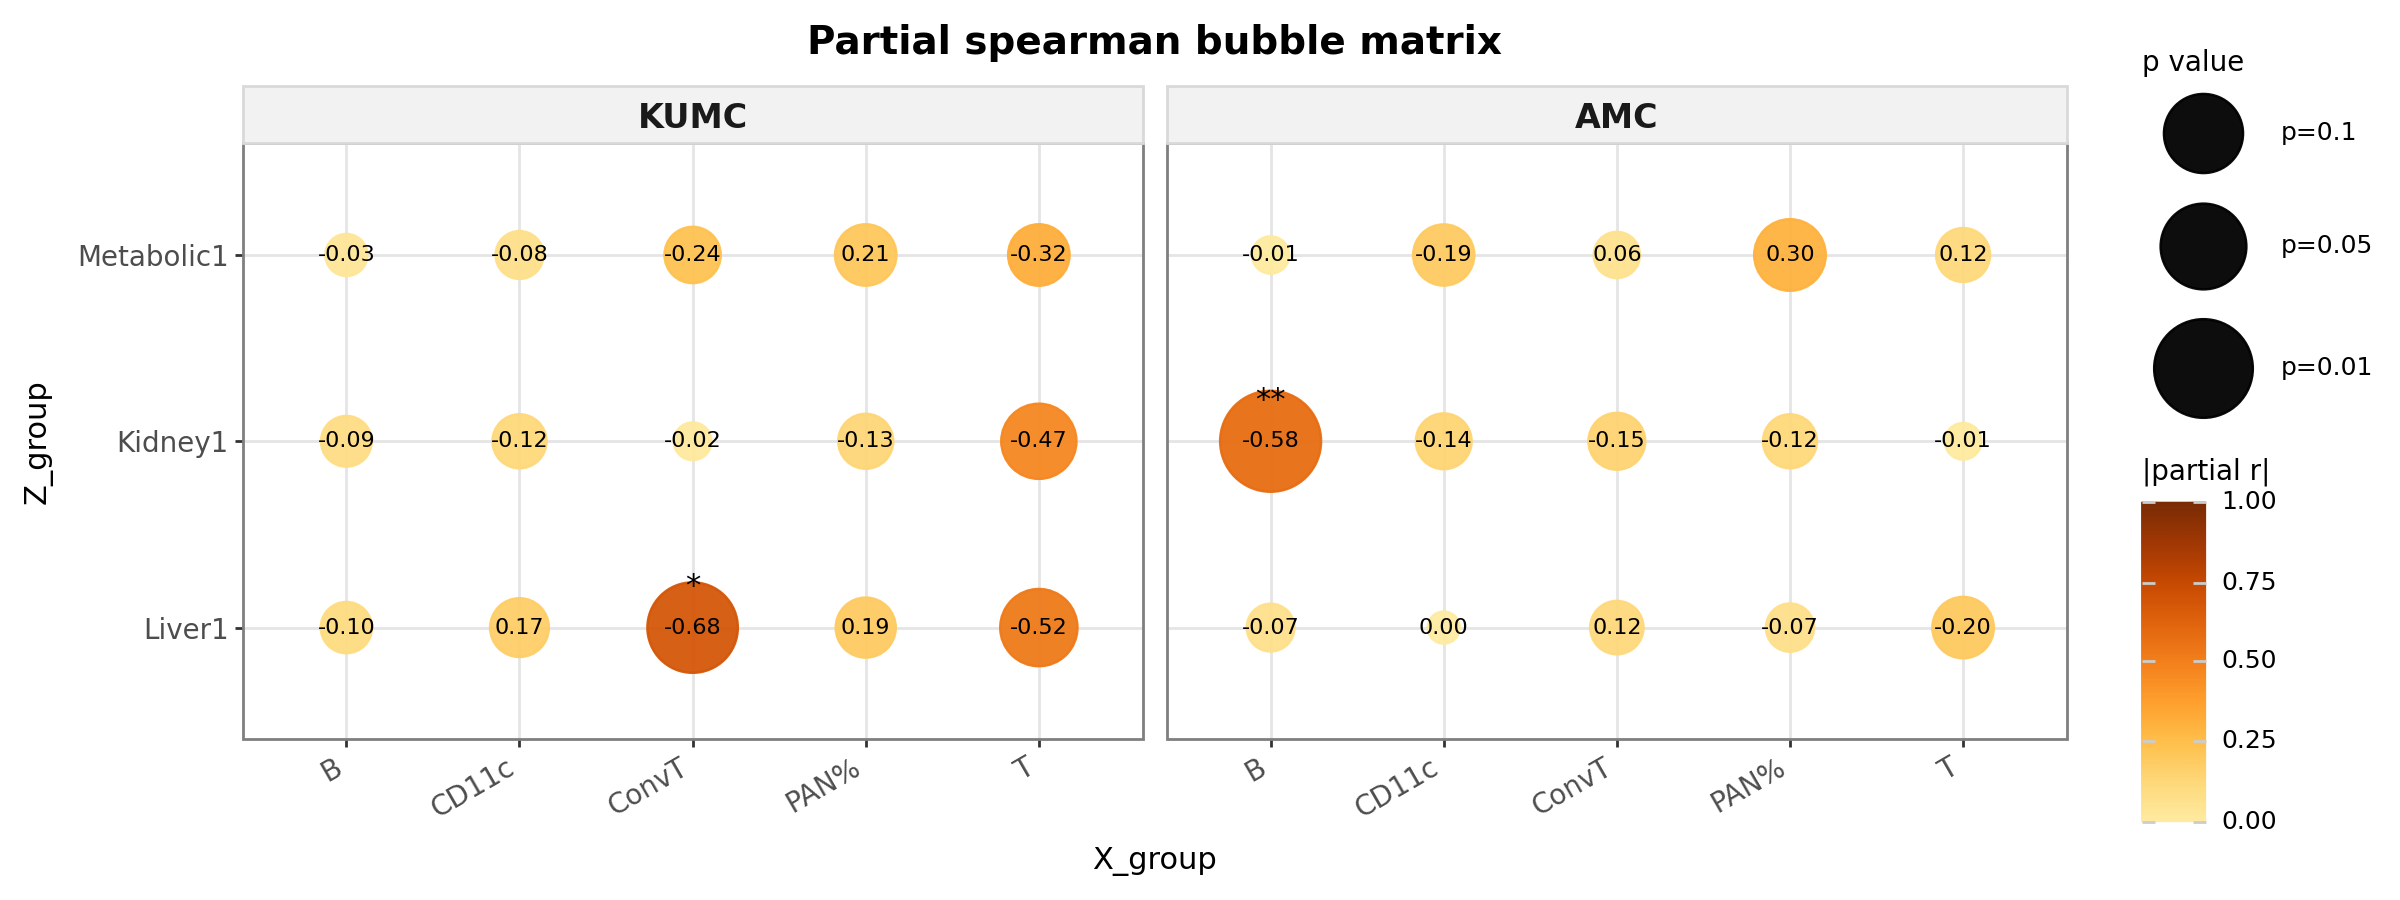

In [49]:
# Visualize

kumc_df = pc1_kumc_s.copy()
amc_df  = pc1_amc_s.copy()

kumc_df["dataset"] = "KUMC"
amc_df["dataset"]  = "AMC"

plot_df = pd.concat([kumc_df, amc_df], axis=0, ignore_index=True)

plot_df["pval"] = pd.to_numeric(plot_df["pval"], errors="coerce")
plot_df["r_partial_spearman"] = pd.to_numeric(plot_df["r_partial_spearman"], errors="coerce")
plot_df["q_fdr_bh_byX"] = pd.to_numeric(plot_df["q_fdr_bh_byX"], errors="coerce")

p_floor = 1e-6
plot_df["neglogp"] = -np.log10(np.clip(plot_df["pval"], p_floor, 1.0))

plot_df["abs_r"] = plot_df["r_partial_spearman"].abs()

plot_df["r_txt"] = plot_df["r_partial_spearman"].map(lambda x: f"{x:.2f}")

def q_to_star(q):
    if pd.isna(q):
        return ""
    elif q < 0.05:
        return "**"
    elif q < 0.10:
        return "*"
    else:
        return ""

plot_df["sig_star"] = plot_df["q_fdr_bh_byX"].apply(q_to_star)

x_order = list(dict.fromkeys(plot_df["X_group"].tolist()))
y_order = list(dict.fromkeys(plot_df["Z_group"].tolist()))

plot_df["X_group"] = pd.Categorical(plot_df["X_group"], categories=x_order, ordered=True)
plot_df["Z_group"] = pd.Categorical(plot_df["Z_group"], categories=y_order, ordered=True)
plot_df["dataset"] = pd.Categorical(plot_df["dataset"], categories=["KUMC", "AMC"], ordered=True)

cmap_use = "YlOrBr"
cmap = cm.get_cmap(cmap_use)

cmap_colors = [mcolors.to_hex(cmap(x)) for x in np.linspace(0.20, 0.95, 9)]

p = (
    ggplot(plot_df, aes(x="X_group", y="Z_group"))
    + geom_point(
        aes(size="neglogp", color="abs_r"),
        alpha=0.95
    )
    + geom_text(
        aes(label="r_txt"),
        size=8,
        color="black"
    )
    + geom_text(
        aes(label="sig_star"),
        nudge_y=0.22,
        size=11,
        color="black"
    )
    + facet_wrap("~dataset", nrow=1)
    + scale_size_continuous(
        range=(6, 20),
        breaks=[-np.log10(0.1), -np.log10(0.05), -np.log10(0.01), -np.log10(0.001)],
        labels=["p=0.1", "p=0.05", "p=0.01", "p=0.001"]
    )
    + scale_color_gradientn(
        colors=cmap_colors,
        limits=(0, 1)
    )
    + labs(
        title="Partial spearman bubble matrix",
        x="X_group",
        y="Z_group",
        size="p value",
        color="|partial r|"
    )
    + theme_bw()
    + theme(
        figure_size=(12, 4.5),
        strip_background=element_rect(fill="#f2f2f2", color="#d9d9d9"),
        strip_text=element_text(size=12, weight="bold"),
        axis_text_x=element_text(size=10, rotation=30, ha="right"),
        axis_text_y=element_text(size=10),
        axis_title=element_text(size=11),
        plot_title=element_text(size=14, weight="bold"),
        legend_title=element_text(size=10),
        legend_text=element_text(size=9)
    )
)

p.save("partial_spearman_bubble_matrix_swapped.svg", verbose=False)
p

### ConvT vs Liver1 (common) 

=== df1 result ===


,dataset,X_var,Y_var,r,p,n,q
0,df1,AST,CD8+T,0.252122,0.454509,13,0.606013
1,df1,AST,CD4+T,0.124865,0.714514,13,0.714514
2,df1,AST,CD8+Treg,-0.335209,0.313593,13,0.606013
3,df1,AST,CD4+Treg,-0.498638,0.118469,13,0.473874
4,df1,ALT,CD8+T,0.289853,0.387264,13,0.516351
5,df1,ALT,CD4+T,0.126808,0.710237,13,0.710237
6,df1,ALT,CD8+Treg,-0.492715,0.123609,13,0.247218
7,df1,ALT,CD4+Treg,-0.727601,0.011150,13,0.044601
8,df1,ALP,CD8+T,0.612998,0.059505,12,0.119009
9,df1,ALP,CD4+T,0.060969,0.867125,12,0.867125


=== df2 result ===


,dataset,X_var,Y_var,r,p,n,q
0,df2,AST,CD8+T,-0.108184,0.649831,22,0.826793
1,df2,AST,CD4+T,0.052260,0.826793,22,0.826793
2,df2,AST,CD8+Treg,0.175313,0.459728,22,0.826793
3,df2,AST,CD4+Treg,0.154278,0.516058,22,0.826793
4,df2,ALT,CD8+T,0.145942,0.539249,22,0.539249
5,df2,ALT,CD4+T,-0.260250,0.267790,22,0.535580
6,df2,ALT,CD8+Treg,0.150934,0.525304,22,0.539249
7,df2,ALT,CD4+Treg,0.300386,0.198153,22,0.535580
8,df2,ALP,CD8+T,0.059899,0.801926,22,0.817772
9,df2,ALP,CD4+T,-0.126264,0.595805,22,0.817772


Common size limits: (0.0007315163825802139, 2.917579704635836)


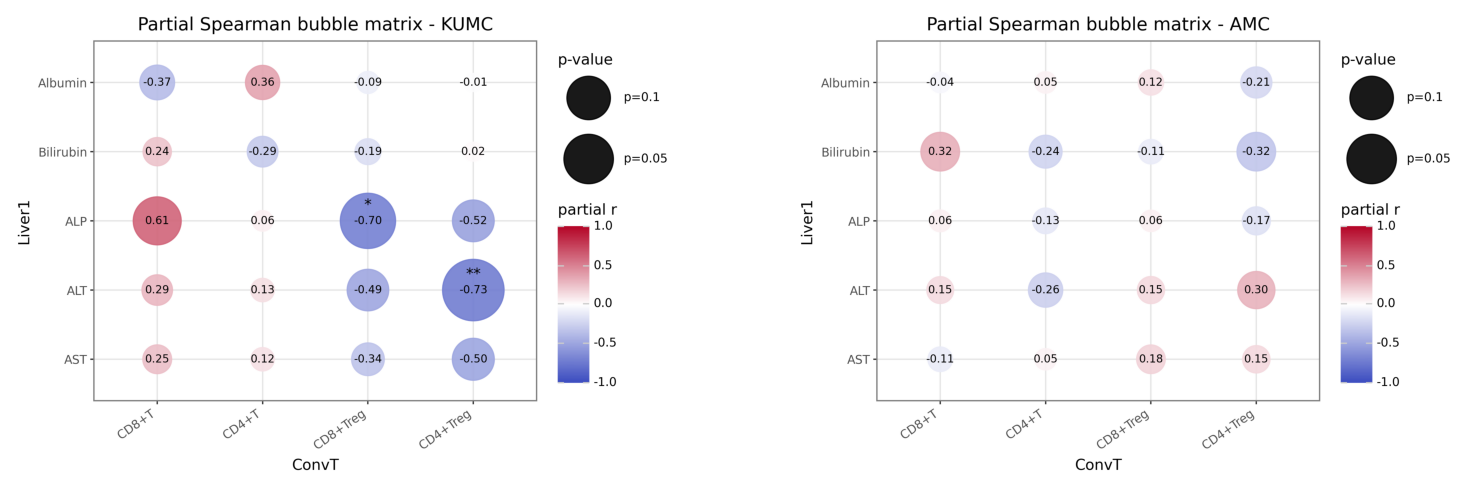

In [50]:
liver_vars = ['AST', 'ALT', 'ALP', 'Bilirubin', 'Albumin']
convt_vars = ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']
covars = ['Sex_01', 'Age']

def run_partial_corr_pg(df, df_name="df"):
    results = []

    for lv in liver_vars:
        for cv in convt_vars:
            needed_cols = [lv, cv] + covars
            sub = df[needed_cols].copy().dropna()

            if len(sub) < 5:
                results.append({
                    "dataset": df_name,
                    "X_var": lv,
                    "Y_var": cv,
                    "r": np.nan,
                    "p": np.nan,
                    "n": len(sub)
                })
                continue

            try:
                out = pg.partial_corr(
                    data=sub,
                    x=lv,
                    y=cv,
                    covar=covars,
                    method='spearman'
                )

                results.append({
                    "dataset": df_name,
                    "X_var": lv,
                    "Y_var": cv,
                    "r": float(out["r"].values[0]),
                    "p": float(out["p-val"].values[0]),
                    "n": len(sub)
                })

            except Exception:
                results.append({
                    "dataset": df_name,
                    "X_var": lv,
                    "Y_var": cv,
                    "r": np.nan,
                    "p": np.nan,
                    "n": len(sub)
                })

    return pd.DataFrame(results)


def add_fdr_by_xvar(res_df, p_col="p", group_col="X_var"):
    df = res_df.copy()
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df["q"] = np.nan

    for _, sub_idx in df.groupby(group_col).groups.items():
        sub_idx = list(sub_idx)
        pvals = df.loc[sub_idx, p_col]

        mask = pvals.notna()
        if mask.sum() == 0:
            continue

        qvals = np.full(len(pvals), np.nan)
        qvals[mask.values] = multipletests(pvals[mask], method="fdr_bh")[1]
        df.loc[sub_idx, "q"] = qvals

    return df


def compute_common_size_limits(res_list, p_floor=1e-6, size_power=1.6):
    all_p = []
    for res_df in res_list:
        pvals = pd.to_numeric(res_df["p"], errors="coerce").dropna().values
        if len(pvals) > 0:
            all_p.extend(pvals.tolist())

    if len(all_p) == 0:
        return (0, 1)

    all_p = np.array(all_p)
    all_neglogp = -np.log10(np.clip(all_p, p_floor, 1.0))
    all_neglogp = all_neglogp ** size_power

    return (float(np.nanmin(all_neglogp)), float(np.nanmax(all_neglogp)))


def q_to_star(q):
    if pd.isna(q):
        return ""
    elif q < 0.05:
        return "**"
    elif q < 0.10:
        return "*"
    else:
        return ""


def bubble_matrix_partialcorr_plotnine(
    res_df: pd.DataFrame,
    X_order=None,
    Y_order=None,
    p_floor=1e-6,
    size_range=(7, 25),
    size_power=1.6,
    size_limits=None,
    figure_size=(6.8, 4.8),
    text_size=8,
    show_text=True,
    title="Partial Spearman bubble matrix",
    legend_ps=(0.1, 0.05, 0.01, 0.001),
    alpha=0.9
):
    df = res_df.copy()

    df["p"] = pd.to_numeric(df["p"], errors="coerce")
    df["r"] = pd.to_numeric(df["r"], errors="coerce")
    df["q"] = pd.to_numeric(df["q"], errors="coerce")

    df = df.dropna(subset=["X_var", "Y_var", "r", "p"]).copy()

    raw_neglogp = -np.log10(np.clip(df["p"].to_numpy(), p_floor, 1.0))
    df["neglogp"] = raw_neglogp ** size_power

    df["r_txt"] = df["r"].map(lambda x: f"{x:.2f}")
    df["sig_star"] = df["q"].apply(q_to_star)

    if X_order is None:
        X_order = list(dict.fromkeys(df["X_var"].tolist()))
    if Y_order is None:
        Y_order = list(dict.fromkeys(df["Y_var"].tolist()))

    df["X_var"] = pd.Categorical(df["X_var"], categories=X_order, ordered=True)
    df["Y_var"] = pd.Categorical(df["Y_var"], categories=Y_order, ordered=True)
    df = df.dropna(subset=["X_var", "Y_var"]).copy()

    legend_ps = list(legend_ps)
    breaks = [(-np.log10(max(p, p_floor))) ** size_power for p in legend_ps]
    labels = [f"p={p:g}" for p in legend_ps]

    p = (
        ggplot(df, aes(x="Y_var", y="X_var"))
        + geom_point(aes(size="neglogp", color="r"), alpha=alpha)
        + scale_size_continuous(
            range=size_range,
            breaks=breaks,
            labels=labels,
            limits=size_limits
        )
        + scale_color_gradient2(
            low="#3B4CC0",
            mid="white",
            high="#B40426",
            midpoint=0,
            limits=(-1, 1)
        )
        + theme_bw()
        + theme(
            figure_size=figure_size,
            axis_text_x=element_text(rotation=35, ha="right")
        )
        + guides(
            size=guide_legend(title="p-value"),
            color=guide_colorbar(title="partial r")
        )
        + labs(title=title, x="ConvT", y="Liver1")
    )

    if show_text:
        p = p + geom_text(
            aes(label="r_txt"),
            size=text_size,
            va="center"
        )

    p = p + geom_text(
        aes(label="sig_star"),
        color="black",
        size=text_size + 3,
        va="bottom",
        nudge_y=0.12
    )

    return p, df


def show_plotnine_side_by_side(p1, p2, figsize=(16, 5), dpi=300):
    buf1 = io.BytesIO()
    p1.save(buf1, format="png", verbose=False, dpi=dpi)
    buf1.seek(0)
    img1 = Image.open(buf1)

    buf2 = io.BytesIO()
    p2.save(buf2, format="png", verbose=False, dpi=dpi)
    buf2.seek(0)
    img2 = Image.open(buf2)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(img1)
    axes[0].axis("off")
    axes[1].imshow(img2)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


res_df1 = run_partial_corr_pg(df1, df_name="df1")
res_df2 = run_partial_corr_pg(df2, df_name="df2")

res_df1 = add_fdr_by_xvar(res_df1, p_col="p", group_col="X_var")
res_df2 = add_fdr_by_xvar(res_df2, p_col="p", group_col="X_var")

print("=== df1 result ===")
display(res_df1)

print("=== df2 result ===")
display(res_df2)

x_order = ['AST', 'ALT', 'ALP', 'Bilirubin', 'Albumin']
y_order = ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg']

common_size_limits = compute_common_size_limits(
    [res_df1, res_df2],
    p_floor=1e-6,
    size_power=1.6
)

print("Common size limits:", common_size_limits)

p_df1, df1_plot = bubble_matrix_partialcorr_plotnine(
    res_df1,
    X_order=x_order,
    Y_order=y_order,
    p_floor=1e-6,
    size_range=(7, 25),
    size_power=1.6,
    size_limits=common_size_limits,
    figure_size=(6.8, 4.8),
    show_text=True,
    title="Partial Spearman bubble matrix - KUMC"
)

p_df2, df2_plot = bubble_matrix_partialcorr_plotnine(
    res_df2,
    X_order=x_order,
    Y_order=y_order,
    p_floor=1e-6,
    size_range=(7, 25),
    size_power=1.6,
    size_limits=common_size_limits,
    figure_size=(6.8, 4.8),
    show_text=True,
    title="Partial Spearman bubble matrix - AMC"
)

p_df1.save("partial_spearman_bubble_matrix_KUMC.svg", verbose=False)
p_df2.save("partial_spearman_bubble_matrix_AMC.svg", verbose=False)

show_plotnine_side_by_side(p_df1, p_df2, figsize=(16, 5))

### B vs Kidney1 (Common)

=== df1 result ===


,dataset,X_var,Y_var,r,p,n,q
0,df1,BUN,Transitional B,-0.029821,0.900678,22,0.900678
1,df1,BUN,Memory B,-0.153010,0.519555,22,0.900678
2,df1,BUN,Early Plasma B,-0.083655,0.725855,22,0.900678
3,df1,BUN,Plasma B,0.042702,0.858132,22,0.900678
4,df1,BUN,ABC,0.055092,0.817557,22,0.900678
5,df1,Cr,Transitional B,0.051485,0.829326,22,0.842832
6,df1,Cr,Memory B,0.047360,0.842832,22,0.842832
7,df1,Cr,Early Plasma B,-0.076801,0.747586,22,0.842832
8,df1,Cr,Plasma B,-0.060299,0.800630,22,0.842832
9,df1,Cr,ABC,-0.142812,0.548077,22,0.842832


=== df2 result ===


,dataset,X_var,Y_var,r,p,n,q
0,df2,BUN,Transitional B,0.488458,0.028872,22,0.077584
1,df2,BUN,Memory B,-0.007878,0.973704,22,0.973704
2,df2,BUN,Early Plasma B,-0.482886,0.031034,22,0.077584
3,df2,BUN,Plasma B,-0.427097,0.060356,22,0.096683
4,df2,BUN,ABC,-0.403935,0.077346,22,0.096683
5,df2,Cr,Transitional B,0.357673,0.121549,22,0.303872
6,df2,Cr,Memory B,-0.003832,0.987207,22,0.987207
7,df2,Cr,Early Plasma B,-0.202274,0.392416,22,0.490521
8,df2,Cr,Plasma B,-0.224886,0.340463,22,0.490521
9,df2,Cr,ABC,-0.456828,0.042880,22,0.214400


Common size limits: (0.00024894604584890497, 1.9944406136128876)


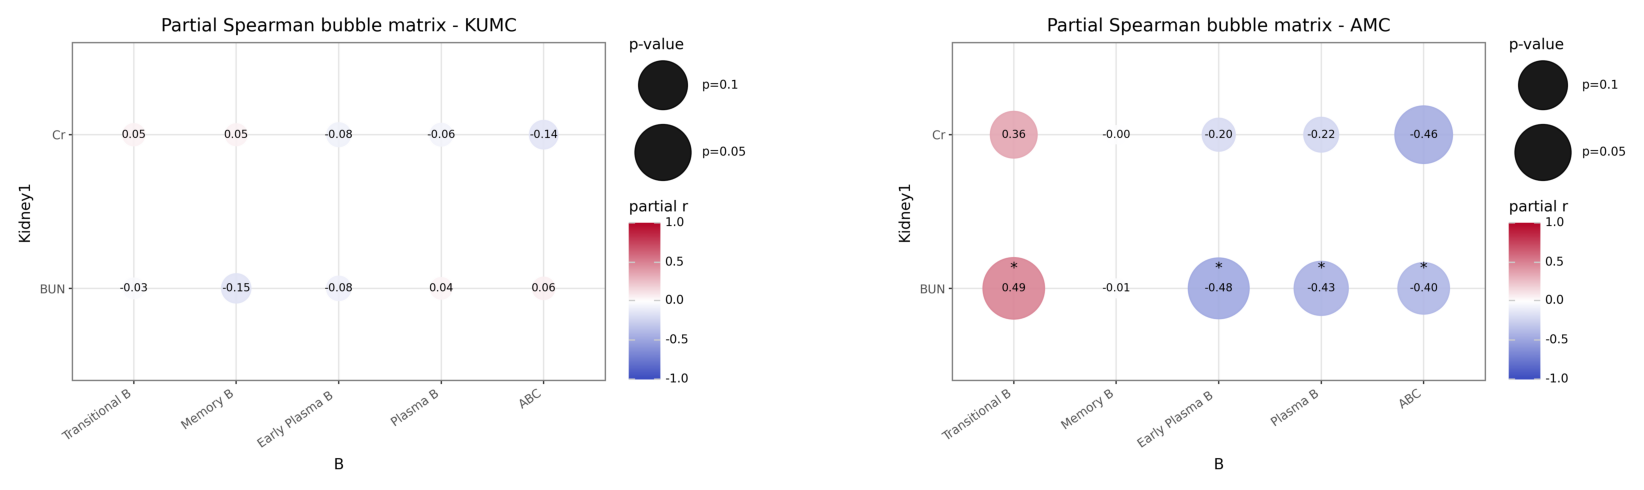

In [51]:
kidney_vars = ['BUN', 'Cr']
B_vars = ["Transitional B", "Memory B", "Early Plasma B ", "Plasma B", "ABC"]
covars = ['Sex_01', 'Age']

def run_partial_corr_pg(df, df_name="df"):
    results = []

    for lv in kidney_vars:
        for cv in B_vars:
            needed_cols = [lv, cv] + covars
            sub = df[needed_cols].copy().dropna()

            if len(sub) < 5:
                results.append({
                    "dataset": df_name,
                    "X_var": lv,
                    "Y_var": cv,
                    "r": np.nan,
                    "p": np.nan,
                    "n": len(sub)
                })
                continue

            try:
                out = pg.partial_corr(
                    data=sub,
                    x=lv,
                    y=cv,
                    covar=covars,
                    method='spearman'
                )

                results.append({
                    "dataset": df_name,
                    "X_var": lv,
                    "Y_var": cv,
                    "r": float(out["r"].values[0]),
                    "p": float(out["p-val"].values[0]),
                    "n": len(sub)
                })

            except Exception:
                results.append({
                    "dataset": df_name,
                    "X_var": lv,
                    "Y_var": cv,
                    "r": np.nan,
                    "p": np.nan,
                    "n": len(sub)
                })

    return pd.DataFrame(results)


def add_fdr_by_xvar(res_df, p_col="p", group_col="X_var"):
    df = res_df.copy()
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df["q"] = np.nan

    for _, sub_idx in df.groupby(group_col).groups.items():
        sub_idx = list(sub_idx)
        pvals = df.loc[sub_idx, p_col]

        mask = pvals.notna()
        if mask.sum() == 0:
            continue

        qvals = np.full(len(pvals), np.nan)
        qvals[mask.values] = multipletests(pvals[mask], method="fdr_bh")[1]
        df.loc[sub_idx, "q"] = qvals

    return df



def compute_common_size_limits(res_list, p_floor=1e-6, size_power=1.6):
    all_p = []
    for res_df in res_list:
        pvals = pd.to_numeric(res_df["p"], errors="coerce").dropna().values
        if len(pvals) > 0:
            all_p.extend(pvals.tolist())

    if len(all_p) == 0:
        return (0, 1)

    all_p = np.array(all_p)
    all_neglogp = -np.log10(np.clip(all_p, p_floor, 1.0))
    all_neglogp = all_neglogp ** size_power

    return (float(np.nanmin(all_neglogp)), float(np.nanmax(all_neglogp)))


def q_to_star(q):
    if pd.isna(q):
        return ""
    elif q < 0.05:
        return "**"
    elif q < 0.10:
        return "*"
    else:
        return ""



def bubble_matrix_partialcorr_plotnine(
    res_df: pd.DataFrame,
    X_order=None,
    Y_order=None,
    p_floor=1e-6,
    size_range=(7, 25),
    size_power=1.6,
    size_limits=None,
    figure_size=(7.6, 4.8),
    text_size=8,
    show_text=True,
    title="Partial Spearman bubble matrix",
    legend_ps=(0.1, 0.05, 0.01, 0.001),
    q_sig=0.05,
    alpha=0.9,
    x_lab="B",
    y_lab="Kidney1"
):
    df = res_df.copy()

    df["p"] = pd.to_numeric(df["p"], errors="coerce")
    df["r"] = pd.to_numeric(df["r"], errors="coerce")
    df["q"] = pd.to_numeric(df["q"], errors="coerce")

    df = df.dropna(subset=["X_var", "Y_var", "r", "p"]).copy()

    raw_neglogp = -np.log10(np.clip(df["p"].to_numpy(), p_floor, 1.0))
    df["neglogp"] = raw_neglogp ** size_power

    df["r_txt"] = df["r"].map(lambda x: f"{x:.2f}")

    if X_order is None:
        X_order = list(dict.fromkeys(df["X_var"].tolist()))
    if Y_order is None:
        Y_order = list(dict.fromkeys(df["Y_var"].tolist()))

    df["X_var"] = pd.Categorical(df["X_var"], categories=X_order, ordered=True)
    df["Y_var"] = pd.Categorical(df["Y_var"], categories=Y_order, ordered=True)
    df = df.dropna(subset=["X_var", "Y_var"]).copy()

    legend_ps = list(legend_ps)
    breaks = [(-np.log10(max(p, p_floor))) ** size_power for p in legend_ps]
    labels = [f"p={p:g}" for p in legend_ps]

    df["sig_star"] = df["q"].apply(q_to_star)

    p = (
        ggplot(df, aes(x="Y_var", y="X_var"))
        + geom_point(aes(size="neglogp", color="r"), alpha=alpha)
        + scale_size_continuous(
            range=size_range,
            breaks=breaks,
            labels=labels,
            limits=size_limits
        )
        + scale_color_gradient2(
            low="#3B4CC0",
            mid="white",
            high="#B40426",
            midpoint=0,
            limits=(-1, 1)
        )
        + theme_bw()
        + theme(
            figure_size=figure_size,
            axis_text_x=element_text(rotation=35, ha="right")
        )
        + guides(
            size=guide_legend(title="p-value"),
            color=guide_colorbar(title="partial r")
        )
        + labs(title=title, x=x_lab, y=y_lab)
    )

    if show_text:
        p = p + geom_text(
            aes(label="r_txt"),
            size=text_size,
            va="center"
        )

    p = p + geom_text(
        aes(label="sig_star"),
        color="black",
        size=text_size + 3,
        va="bottom",
        nudge_y=0.08
    )

    return p, df


def show_plotnine_side_by_side(p1, p2, figsize=(18, 5), dpi=300):
    buf1 = io.BytesIO()
    p1.save(buf1, format="png", verbose=False, dpi=dpi)
    buf1.seek(0)
    img1 = Image.open(buf1)

    buf2 = io.BytesIO()
    p2.save(buf2, format="png", verbose=False, dpi=dpi)
    buf2.seek(0)
    img2 = Image.open(buf2)

    fig, axes = plt.subplots(1, 2, figsize=figsize)
    axes[0].imshow(img1)
    axes[0].axis("off")
    axes[1].imshow(img2)
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


res_df1 = run_partial_corr_pg(df1, df_name="df1")
res_df2 = run_partial_corr_pg(df2, df_name="df2")

res_df1 = add_fdr_by_xvar(res_df1, p_col="p", group_col="X_var")
res_df2 = add_fdr_by_xvar(res_df2, p_col="p", group_col="X_var")

print("=== df1 result ===")
display(res_df1)

print("=== df2 result ===")
display(res_df2)


x_order = ['BUN', 'Cr']
y_order = ["Transitional B", "Memory B", "Early Plasma B ", "Plasma B", "ABC"]


common_size_limits = compute_common_size_limits(
    [res_df1, res_df2],
    p_floor=1e-6,
    size_power=1.6
)

print("Common size limits:", common_size_limits)


p_df1, df1_plot = bubble_matrix_partialcorr_plotnine(
    res_df1,
    X_order=x_order,
    Y_order=y_order,
    p_floor=1e-6,
    size_range=(7, 25),
    size_power=1.6,
    size_limits=common_size_limits,
    figure_size=(7.6, 4.8),
    show_text=True,
    q_sig=0.05,
    title="Partial Spearman bubble matrix - KUMC",
    x_lab="B",
    y_lab="Kidney1"
)

p_df2, df2_plot = bubble_matrix_partialcorr_plotnine(
    res_df2,
    X_order=x_order,
    Y_order=y_order,
    p_floor=1e-6,
    size_range=(7, 25),
    size_power=1.6,
    size_limits=common_size_limits,
    figure_size=(7.6, 4.8),
    show_text=True,
    q_sig=0.05,
    title="Partial Spearman bubble matrix - AMC",
    x_lab="B",
    y_lab="Kidney1"
)


p_df1.save("partial_spearman_bubble_matrix_kidney_B_KUMC.svg", verbose=False)
p_df2.save("partial_spearman_bubble_matrix_kidney_B_AMC.svg", verbose=False)

show_plotnine_side_by_side(p_df1, p_df2, figsize=(18, 5))

### KidneyAMC ('GFR(CKD_EPI)', 'CrCl', 'BUN', 'Cr')


[AMC | PC1 vs PC1 | partial Spearman | covars = Age, Sex_01]

dataset   method    X_group Z_group  n  pc1var_X  pc1var_Z  r_partial_spearman   pval  q_fdr_bh_all  q_fdr_bh_byZ          CI95%
    AMC spearman Kidney_amc       B 22    0.4002    0.6107             -0.4896 0.0284        0.1421        0.0284 [-0.77, -0.06]
    AMC spearman Kidney_amc    PAN% 22    0.4002    0.3529             -0.2970 0.2035        0.5088        0.2035  [-0.65, 0.17]
    AMC spearman Kidney_amc   ConvT 22    0.4002    0.5460             -0.2255 0.3392        0.5653        0.3392  [-0.61, 0.24]
    AMC spearman Kidney_amc       T 22    0.4002    0.6073             -0.1373 0.5637        0.7046        0.5637  [-0.55, 0.32]
    AMC spearman Kidney_amc   CD11c 22    0.4002    0.6616             -0.0008 0.9972        0.9972        0.9972  [-0.44, 0.44]


C:\Users\nva_kist\AppData\Local\Temp\ipykernel_34724\548241566.py:212: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.


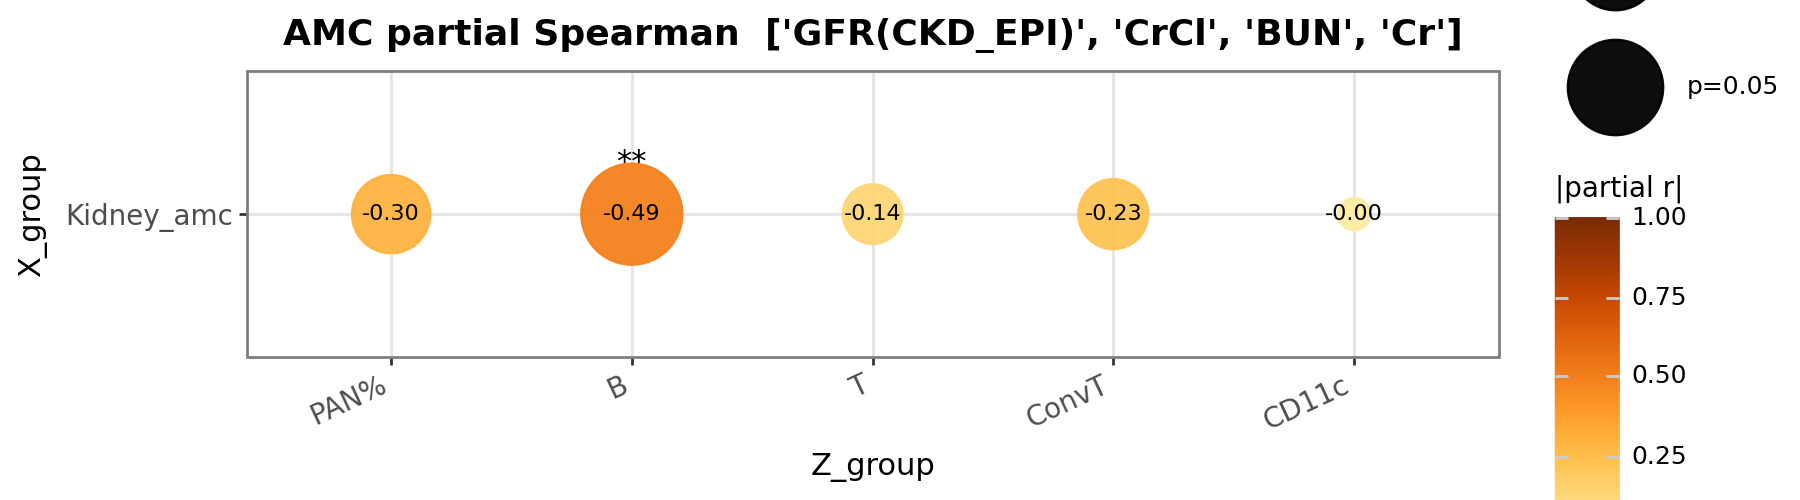

In [52]:
df = df2.copy()   # AMC
covars = ["Age", "Sex_01"]
min_n_pca = 5
min_n_corr = 10

X_groups = {
    "Kidney_amc": ['GFR(CKD_EPI)', 'CrCl', 'BUN', 'Cr'],
}

Z_groups = {
    "PAN%": ['B', 'CD11b', 'HLADR', 'NK', 'NKT1', 'T'],
    "B": ["Transitional B", "Memory B", "Early Plasma B ", "Plasma B", "ABC"],
    "T": ['NKT2', 'MAIT', 'gd1T', 'gd2T', 'ConvT%'],
    "ConvT": ['CD8+T', 'CD4+T', 'CD8+Treg', 'CD4+Treg'],
    "CD11c": ['CD11c+CD206-', 'CD11c+CD206+', 'CD11c-CD206+', 'CD11c-CD206-'],
}

def run_group_pca(df, group_dict, prefix, min_n=5):
    score_df = pd.DataFrame(index=df.index)
    meta_rows = []
    loading_dict = {}

    for gname, cols in group_dict.items():
        cols_exist = [c for c in cols if c in df.columns]

        if len(cols_exist) < 2:
            print(f"[SKIP] {gname}: usable columns < 2")
            continue

        sub = df[cols_exist].copy().dropna()

        if sub.shape[0] < min_n:
            print(f"[SKIP] {gname}: n < {min_n}")
            continue

        X = sub.astype(float).values
        Xz = StandardScaler().fit_transform(X)

        pca = PCA(n_components=1)
        pc1 = pca.fit_transform(Xz).ravel()

        loadings = pd.Series(pca.components_[0], index=cols_exist, name="PC1")

        if loadings.sum() < 0:
            loadings *= -1
            pc1 *= -1

        score_col = f"{prefix}_{gname}_PC1"
        score_df[score_col] = pd.Series(pc1, index=sub.index).reindex(df.index)

        meta_rows.append({
            "group": gname,
            "prefix": prefix,
            "n_features": len(cols_exist),
            "n_samples_used": sub.shape[0],
            "features": ", ".join(cols_exist),
            "explained_var_PC1": float(pca.explained_variance_ratio_[0])
        })

        loading_dict[gname] = loadings.to_frame()

    meta_df = pd.DataFrame(meta_rows)
    return score_df, meta_df, loading_dict

X_score_df, X_meta_df, X_loading_dict = run_group_pca(
    df=df,
    group_dict=X_groups,
    prefix="X",
    min_n=min_n_pca
)

Z_score_df, Z_meta_df, Z_loading_dict = run_group_pca(
    df=df,
    group_dict=Z_groups,
    prefix="Z",
    min_n=min_n_pca
)

group_score_df = pd.concat([X_score_df, Z_score_df], axis=1)

# explained variance 매핑
x_var_map = X_meta_df.set_index("group")["explained_var_PC1"].to_dict()
z_var_map = Z_meta_df.set_index("group")["explained_var_PC1"].to_dict()

results = []

for xg in X_groups.keys():
    xcol = f"X_{xg}_PC1"
    if xcol not in group_score_df.columns:
        continue

    for zg in Z_groups.keys():
        zcol = f"Z_{zg}_PC1"
        if zcol not in group_score_df.columns:
            continue

        use_cols = [xcol, zcol] + covars
        sub = pd.concat([group_score_df, df[covars]], axis=1)[use_cols].dropna().copy()

        if len(sub) < min_n_corr:
            results.append({
                "X_group": xg,
                "Z_group": zg,
                "n": len(sub),
                "r_partial_spearman": np.nan,
                "pval": np.nan,
                "CI95%": np.nan
            })
            continue

        try:
            out = pg.partial_corr(
                data=sub,
                x=xcol,
                y=zcol,
                covar=covars,
                method="spearman"
            )

            results.append({
                "X_group": xg,
                "Z_group": zg,
                "n": int(out["n"].iloc[0]) if "n" in out.columns else len(sub),
                "r_partial_spearman": float(out["r"].iloc[0]),
                "pval": float(out["p-val"].iloc[0]),
                "CI95%": out["CI95%"].iloc[0] if "CI95%" in out.columns else np.nan
            })

        except Exception as e:
            print(f"[ERROR] {xg} vs {zg}: {e}")
            results.append({
                "X_group": xg,
                "Z_group": zg,
                "n": len(sub),
                "r_partial_spearman": np.nan,
                "pval": np.nan,
                "CI95%": np.nan
            })

pc1_amc_s = pd.DataFrame(results)


pc1_amc_s["q_fdr_bh_all"] = np.nan
mask_all = pc1_amc_s["pval"].notna()
if mask_all.sum() > 0:
    pc1_amc_s.loc[mask_all, "q_fdr_bh_all"] = multipletests(
        pc1_amc_s.loc[mask_all, "pval"],
        method="fdr_bh"
    )[1]

pc1_amc_s["q_fdr_bh_byZ"] = np.nan
for zg, sub_idx in pc1_amc_s.groupby("Z_group").groups.items():
    sub_mask = pc1_amc_s.index.isin(sub_idx) & pc1_amc_s["pval"].notna()
    pvals = pc1_amc_s.loc[sub_mask, "pval"].values

    if len(pvals) > 0:
        qvals = multipletests(pvals, method="fdr_bh")[1]
        pc1_amc_s.loc[sub_mask, "q_fdr_bh_byZ"] = qvals

pc1_amc_s["pc1var_X"] = pc1_amc_s["X_group"].map(x_var_map)
pc1_amc_s["pc1var_Z"] = pc1_amc_s["Z_group"].map(z_var_map)
pc1_amc_s["dataset"] = "AMC"
pc1_amc_s["method"] = "spearman"

pc1_amc_s = pc1_amc_s[
    ["dataset", "method", "X_group", "Z_group", "n",
     "pc1var_X", "pc1var_Z",
     "r_partial_spearman", "pval", "q_fdr_bh_all", "q_fdr_bh_byZ", "CI95%"]
].sort_values(
    ["X_group", "q_fdr_bh_byZ", "pval", "Z_group"],
    na_position="last"
).reset_index(drop=True)


print("\n[AMC | PC1 vs PC1 | partial Spearman | covars = Age, Sex_01]\n")
print(pc1_amc_s.round(4).to_string(index=False))

plot_df = pc1_amc_s.copy()

plot_df["pval"] = pd.to_numeric(plot_df["pval"], errors="coerce")
plot_df["r_partial_spearman"] = pd.to_numeric(plot_df["r_partial_spearman"], errors="coerce")
plot_df["q_fdr_bh_byZ"] = pd.to_numeric(plot_df["q_fdr_bh_byZ"], errors="coerce")

p_floor = 1e-6
plot_df["neglogp"] = -np.log10(np.clip(plot_df["pval"], p_floor, 1.0))

plot_df["abs_r"] = plot_df["r_partial_spearman"].abs()

plot_df["r_txt"] = plot_df["r_partial_spearman"].map(
    lambda x: f"{x:.2f}" if pd.notna(x) else ""
)

def q_to_star(q):
    if pd.isna(q):
        return ""
    elif q < 0.05:
        return "**"
    elif q < 0.10:
        return "*"
    else:
        return ""

plot_df["sig_star"] = plot_df["q_fdr_bh_byZ"].apply(q_to_star)

x_order = ["PAN%", "B", "T", "ConvT", "CD11c"]
y_order = ["Kidney_amc"]

plot_df["Z_group"] = pd.Categorical(plot_df["Z_group"], categories=x_order, ordered=True)
plot_df["X_group"] = pd.Categorical(plot_df["X_group"], categories=y_order, ordered=True)

cmap_use = "YlOrBr"
cmap = cm.get_cmap(cmap_use)
cmap_colors = [mcolors.to_hex(cmap(x)) for x in np.linspace(0.20, 0.95, 9)]

p = (
    ggplot(plot_df, aes(x="Z_group", y="X_group"))
    + geom_point(
        aes(size="neglogp", color="abs_r"),
        alpha=0.95
    )
    + geom_text(
        aes(label="r_txt"),
        size=8,
        color="black"
    )
    + geom_text(
        aes(label="sig_star"),
        nudge_y=0.18,
        size=11,
        color="black"
    )
    + scale_size_continuous(
        range=(6, 20),
        breaks=[-np.log10(0.1), -np.log10(0.05), -np.log10(0.01), -np.log10(0.001)],
        labels=["p=0.1", "p=0.05", "p=0.01", "p=0.001"]
    )
    + scale_color_gradientn(
        colors=cmap_colors,
        limits=(0, 1)
    )
    + labs(
        title="AMC partial Spearman  ['GFR(CKD_EPI)', 'CrCl', 'BUN', 'Cr']",
        x="Z_group",
        y="X_group",
        size="p value",
        color="|partial r|"
    )
    + theme_bw()
    + theme(
        figure_size=(9, 2.5),
        strip_background=element_rect(fill="#f2f2f2", color="#d9d9d9"),
        strip_text=element_text(size=12, weight="bold"),
        axis_text_x=element_text(size=10, rotation=25, ha="right"),
        axis_text_y=element_text(size=10),
        axis_title=element_text(size=11),
        plot_title=element_text(size=13, weight="bold"),
        legend_title=element_text(size=10),
        legend_text=element_text(size=9)
    )
)

p

=== AMC result ===


,dataset,X_var,Y_var,r,p,n,q
0,AMC,GFR(CKD_EPI),Transitional B,-0.253994,0.279873,22,0.667279
1,AMC,GFR(CKD_EPI),Memory B,0.151114,0.524804,22,0.667279
2,AMC,GFR(CKD_EPI),Early Plasma B,0.281284,0.229601,22,0.667279
3,AMC,GFR(CKD_EPI),Plasma B,0.100094,0.674580,22,0.674580
4,AMC,GFR(CKD_EPI),ABC,0.147877,0.533823,22,0.667279
5,AMC,CrCl,Transitional B,-0.143263,0.546802,22,0.815414
6,AMC,CrCl,Memory B,0.055750,0.815414,22,0.815414
7,AMC,CrCl,Early Plasma B,-0.105372,0.658394,22,0.815414
8,AMC,CrCl,Plasma B,0.097863,0.681467,22,0.815414
9,AMC,CrCl,ABC,0.416567,0.067690,22,0.338448


Size limits: (0.02070456159860279, 1.2846568801301985)


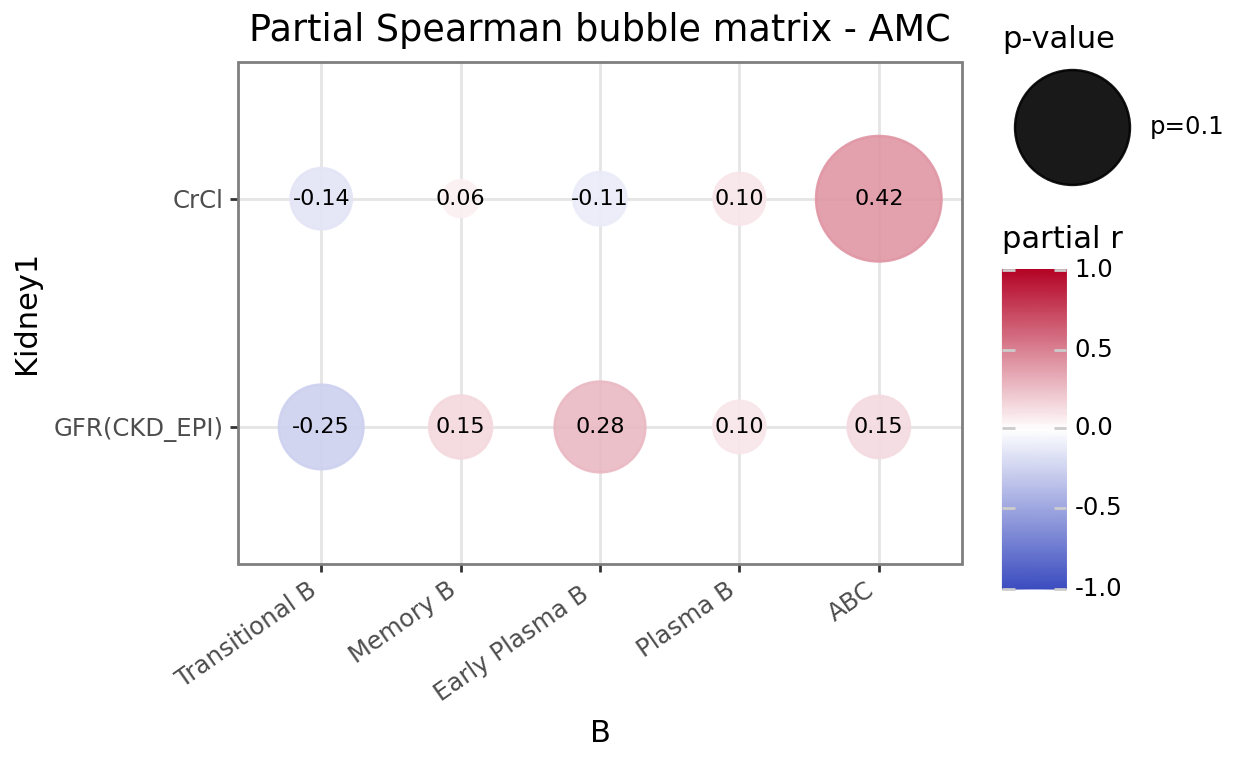

In [5]:
kidney_vars = ['GFR(CKD_EPI)', 'CrCl']
B_vars = ["Transitional B", "Memory B", "Early Plasma B ", "Plasma B", "ABC"]
covars = ['Sex_01', 'Age']

def run_partial_corr_pg(df, df_name="df"):
    results = []

    for lv in kidney_vars:
        for cv in B_vars:
            needed_cols = [lv, cv] + covars
            sub = df[needed_cols].copy().dropna()

            if len(sub) < 5:
                results.append({
                    "dataset": df_name,
                    "X_var": lv,
                    "Y_var": cv,
                    "r": np.nan,
                    "p": np.nan,
                    "n": len(sub)
                })
                continue

            try:
                out = pg.partial_corr(
                    data=sub,
                    x=lv,
                    y=cv,
                    covar=covars,
                    method='spearman'
                )

                results.append({
                    "dataset": df_name,
                    "X_var": lv,
                    "Y_var": cv,
                    "r": float(out["r"].values[0]),
                    "p": float(out["p-val"].values[0]),
                    "n": len(sub)
                })

            except Exception:
                results.append({
                    "dataset": df_name,
                    "X_var": lv,
                    "Y_var": cv,
                    "r": np.nan,
                    "p": np.nan,
                    "n": len(sub)
                })

    return pd.DataFrame(results)


def add_fdr_by_xvar(res_df, p_col="p", group_col="X_var"):
    df = res_df.copy()
    df[p_col] = pd.to_numeric(df[p_col], errors="coerce")
    df["q"] = np.nan

    for _, sub_idx in df.groupby(group_col).groups.items():
        sub_idx = list(sub_idx)
        pvals = df.loc[sub_idx, p_col]

        mask = pvals.notna()
        if mask.sum() == 0:
            continue

        qvals = np.full(len(pvals), np.nan)
        qvals[mask.values] = multipletests(pvals[mask], method="fdr_bh")[1]
        df.loc[sub_idx, "q"] = qvals

    return df


def compute_size_limits(res_df, p_floor=1e-6, size_power=1.6):
    pvals = pd.to_numeric(res_df["p"], errors="coerce").dropna().values

    if len(pvals) == 0:
        return (0, 1)

    neglogp = -np.log10(np.clip(pvals, p_floor, 1.0))
    neglogp = neglogp ** size_power
    return (float(np.nanmin(neglogp)), float(np.nanmax(neglogp)))


def q_to_star(q):
    if pd.isna(q):
        return ""
    elif q < 0.05:
        return "**"
    elif q < 0.10:
        return "*"
    else:
        return ""


def bubble_matrix_partialcorr_plotnine(
    res_df: pd.DataFrame,
    X_order=None,
    Y_order=None,
    p_floor=1e-6,
    size_range=(7, 25),
    size_power=1.6,
    size_limits=None,
    figure_size=(7.6, 4.8),
    text_size=8,
    show_text=True,
    title="Partial Spearman bubble matrix - AMC",
    legend_ps=(0.1, 0.05, 0.01, 0.001),
    q_sig=0.05,
    alpha=0.9,
    x_lab="B",
    y_lab="Kidney1"
):
    df = res_df.copy()

    df["p"] = pd.to_numeric(df["p"], errors="coerce")
    df["r"] = pd.to_numeric(df["r"], errors="coerce")
    df["q"] = pd.to_numeric(df["q"], errors="coerce")

    df = df.dropna(subset=["X_var", "Y_var", "r", "p"]).copy()

    raw_neglogp = -np.log10(np.clip(df["p"].to_numpy(), p_floor, 1.0))
    df["neglogp"] = raw_neglogp ** size_power

    df["r_txt"] = df["r"].map(lambda x: f"{x:.2f}")
    df["sig_star"] = df["q"].apply(q_to_star)

    if X_order is None:
        X_order = list(dict.fromkeys(df["X_var"].tolist()))
    if Y_order is None:
        Y_order = list(dict.fromkeys(df["Y_var"].tolist()))

    df["X_var"] = pd.Categorical(df["X_var"], categories=X_order, ordered=True)
    df["Y_var"] = pd.Categorical(df["Y_var"], categories=Y_order, ordered=True)
    df = df.dropna(subset=["X_var", "Y_var"]).copy()

    legend_ps = list(legend_ps)
    breaks = [(-np.log10(max(p, p_floor))) ** size_power for p in legend_ps]
    labels = [f"p={p:g}" for p in legend_ps]

    p = (
        ggplot(df, aes(x="Y_var", y="X_var"))
        + geom_point(aes(size="neglogp", color="r"), alpha=alpha)
        + scale_size_continuous(
            range=size_range,
            breaks=breaks,
            labels=labels,
            limits=size_limits
        )
        + scale_color_gradient2(
            low="#3B4CC0",
            mid="white",
            high="#B40426",
            midpoint=0,
            limits=(-1, 1)
        )
        + theme_bw()
        + theme(
            figure_size=figure_size,
            axis_text_x=element_text(rotation=35, ha="right")
        )
        + guides(
            size=guide_legend(title="p-value"),
            color=guide_colorbar(title="partial r")
        )
        + labs(title=title, x=x_lab, y=y_lab)
    )

    if show_text:
        p = p + geom_text(
            aes(label="r_txt"),
            size=text_size,
            va="center"
        )

    p = p + geom_text(
        aes(label="sig_star"),
        color="black",
        size=text_size + 3,
        va="bottom",
        nudge_y=0.08
    )

    return p, df


res_df2 = run_partial_corr_pg(df2, df_name="AMC")
res_df2 = add_fdr_by_xvar(res_df2, p_col="p", group_col="X_var")

print("=== AMC result ===")
display(res_df2)

x_order = ['GFR(CKD_EPI)', 'CrCl']
y_order = ["Transitional B", "Memory B", "Early Plasma B ", "Plasma B", "ABC"]

size_limits = compute_size_limits(
    res_df2,
    p_floor=1e-6,
    size_power=1.6
)

print("Size limits:", size_limits)

p_df2, df2_plot = bubble_matrix_partialcorr_plotnine(
    res_df2,
    X_order=x_order,
    Y_order=y_order,
    p_floor=1e-6,
    size_range=(7, 25),
    size_power=1.6,
    size_limits=size_limits,
    figure_size=(6.2, 3.8),
    show_text=True,
    q_sig=0.05,
    title="Partial Spearman bubble matrix - AMC",
    x_lab="B",
    y_lab="Kidney1"
)

p_df2.save("Kidney_AMC_B_spearman_GFR_CrCl_only.svg", verbose=False)
p_df2